## Part 0: Building the Analytical Table (1 pt)

### 0.1 Class-pooled master table

In [1]:
import pandas as pd
from pathlib import Path
from zipfile import ZipFile
from IPython.display import display

zip_path = Path("../Datos/shared.zip")
extract_dir = Path("../Datos/shared")

# Extraer el zip solo si aún no existe la carpeta shared
if zip_path.exists() and not extract_dir.exists():
    extract_dir.mkdir(parents=True, exist_ok=True)
    with ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)
    print("ZIP extraído en", extract_dir)

print("\n¿Existe ZIP?", zip_path.exists())
print("¿Existe carpeta shared?", extract_dir.exists())

def build_master(prefix):
    files = sorted(extract_dir.rglob(f"{prefix}_team*.csv"))
    ok = []
    bad = []

    for f in files:
        try:
            df = pd.read_csv(f)
            df["source_file"] = f.name
            ok.append(df)
        except Exception as e:
            bad.append((f.name, str(e)))

    master = pd.concat(ok, ignore_index=True) if ok else pd.DataFrame()

    if not master.empty and "codigo_comuna" in master.columns:
        master["codigo_comuna"] = pd.to_numeric(
            master["codigo_comuna"], errors="coerce"
        ).astype("Int64")

    return master, files, bad

census_master, census_files, census_bad = build_master("census")
eno_master, eno_files, eno_bad = build_master("eno")
grd_master, grd_files, grd_bad = build_master("grd")

print("\nArchivos encontrados")
print("Census", len(census_files))
print("ENO", len(eno_files))
print("GRD", len(grd_files))

print("\nArchivos con error")
print("Census", census_bad if census_bad else "ninguno")
print("ENO", eno_bad if eno_bad else "ninguno")
print("GRD", grd_bad if grd_bad else "ninguno")

def resumen_master(df, nombre):
    print(f"\n{nombre}")

    if df.empty:
        print("DataFrame vacío")
        return

    if "codigo_comuna" not in df.columns:
        print("No existe la columna codigo_comuna")
        print("Columnas disponibles")
        print(df.columns.tolist())
        return

    n_rows = len(df)
    n_unique = df["codigo_comuna"].nunique(dropna=True)

    print("filas totales", n_rows)
    print("codigo_comuna únicos", n_unique)

    if n_rows != n_unique:
        print("Hay duplicados por comuna")
        display(
            df[df["codigo_comuna"].duplicated(keep=False)]
            [["codigo_comuna", "source_file"]]
            .sort_values(["codigo_comuna", "source_file"])
            .drop_duplicates()
        )
    else:
        print("OK, una fila por comuna")

resumen_master(census_master, "CENSUS MASTER")
resumen_master(eno_master, "ENO MASTER")
resumen_master(grd_master, "GRD MASTER")

if not census_master.empty and not eno_master.empty and not grd_master.empty:
    census_set = set(census_master["codigo_comuna"].dropna().astype(int))
    eno_set = set(eno_master["codigo_comuna"].dropna().astype(int))
    grd_set = set(grd_master["codigo_comuna"].dropna().astype(int))

    print("\nCobertura entre datasets")
    print("En census y no en ENO", sorted(census_set - eno_set))
    print("En census y no en GRD", sorted(census_set - grd_set))
    print("En ENO y no en census", sorted(eno_set - census_set))
    print("En GRD y no en census", sorted(grd_set - census_set))
    print("En ENO y no en GRD", sorted(eno_set - grd_set))
    print("En GRD y no en ENO", sorted(grd_set - eno_set))

    final_n = len(census_set & eno_set & grd_set)
    print("\nN final con comunas presentes en los tres datasets", final_n)

    # --------------------------------------------------
    # Archivos problemáticos por asimetría de cobertura
    # --------------------------------------------------
    problem_codes = sorted(
        (census_set - eno_set)
        | (census_set - grd_set)
        | (eno_set - census_set)
        | (eno_set - grd_set)
        | (grd_set - census_set)
        | (grd_set - eno_set)
    )

    print("\nComunas problemáticas detectadas")
    print(problem_codes)

    if problem_codes:
        print("\nFilas problemáticas en CENSUS")
        census_problem = (
            census_master[census_master["codigo_comuna"].isin(problem_codes)]
            [["codigo_comuna", "nombre_comuna", "source_file"]]
            .sort_values(["codigo_comuna", "source_file"])
            .drop_duplicates()
        )
        display(census_problem)

        print("Archivos de CENSUS involucrados")
        print(sorted(census_problem["source_file"].dropna().unique().tolist()))

        print("\nFilas problemáticas en ENO")
        eno_problem = (
            eno_master[eno_master["codigo_comuna"].isin(problem_codes)]
            [["codigo_comuna", "nombre_comuna", "source_file"]]
            .sort_values(["codigo_comuna", "source_file"])
            .drop_duplicates()
        )
        display(eno_problem)

        print("Archivos de ENO involucrados")
        print(sorted(eno_problem["source_file"].dropna().unique().tolist()))

        print("\nFilas problemáticas en GRD")
        grd_problem = (
            grd_master[grd_master["codigo_comuna"].isin(problem_codes)]
            [["codigo_comuna", "nombre_comuna", "source_file"]]
            .sort_values(["codigo_comuna", "source_file"])
            .drop_duplicates()
        )
        display(grd_problem)

        print("Archivos de GRD involucrados")
        print(sorted(grd_problem["source_file"].dropna().unique().tolist()))
    else:
        print("\nNo se detectaron archivos problemáticos por cobertura.")

ZIP extraído en ..\Datos\shared

¿Existe ZIP? True
¿Existe carpeta shared? True

Archivos encontrados
Census 12
ENO 12
GRD 12

Archivos con error
Census ninguno
ENO ninguno
GRD ninguno

CENSUS MASTER
filas totales 32
codigo_comuna únicos 32
OK, una fila por comuna

ENO MASTER
filas totales 32
codigo_comuna únicos 32
OK, una fila por comuna

GRD MASTER
filas totales 32
codigo_comuna únicos 32
OK, una fila por comuna

Cobertura entre datasets
En census y no en ENO []
En census y no en GRD []
En ENO y no en census []
En GRD y no en census []
En ENO y no en GRD []
En GRD y no en ENO []

N final con comunas presentes en los tres datasets 32

Comunas problemáticas detectadas
[]

No se detectaron archivos problemáticos por cobertura.


In this section, we built three master tables using the course data, one for Census, one for ENO, and one for GRD. We then checked that each comuna appeared only once and that the three datasets covered the same comunas.
We also reviewed our assigned comunas to make sure they were included correctly before continuing with the analysis. During this process, some files from group 07 showed inconsistencies. For example, the ENO dataset did not include the comuna name, and in the GRD dataset some columns were not correctly ordered. Because of this, those files were removed to keep the final dataset clean and reliable.

In [2]:
my_comunas = [13301, 13501, 13601]

print("Visualización de nuestras comunas en Census")
display(census_master[census_master["codigo_comuna"].isin(my_comunas)].sort_values("codigo_comuna"))

print("Visualización de nuestras comunas en ENO")
display(eno_master[eno_master["codigo_comuna"].isin(my_comunas)].sort_values("codigo_comuna"))

print("Visualización de nuestras comunas en GRD")
display(grd_master[grd_master["codigo_comuna"].isin(my_comunas)].sort_values("codigo_comuna"))

Visualización de nuestras comunas en Census


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio,source_file
11,13301,Colina,173293,149378,22498,13.09,33.0,35.0,12.61,12.78,59.95,70.00,45.82,census_team10.csv
12,13501,Melipilla,136325,124407,11069,8.17,37.0,30.0,11.07,11.26,58.93,74.38,50.48,census_team10.csv
13,13601,Talagante,76429,71322,4559,6.01,36.0,32.0,11.83,12.26,59.75,69.74,46.76,census_team10.csv


Visualización de nuestras comunas en ENO


,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k,source_file
11,13301,Colina,1259,576,174,509,Parotiditis | VIH | Sifilis,72.65,eno_team10.csv
12,13501,Melipilla,824,387,245,192,VIH | Chagas | Parotiditis,60.44,eno_team10.csv
13,13601,Talagante,314,186,32,96,VIH | Parotiditis | Chagas,41.08,eno_team10.csv


Visualización de nuestras comunas en GRD


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k,source_file
11,13301,Colina,14742,12697,2045,13.87,5.88,6.06,4.72,1.41,2.04,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",850.70,grd_team10.csv
12,13501,Melipilla,29404,26882,2522,8.58,4.98,5.09,3.89,1.23,2.23,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",2156.90,grd_team10.csv
13,13601,Talagante,12342,11754,588,4.76,6.46,6.53,5.09,1.63,2.60,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",1614.83,grd_team10.csv


This code checks whether our assigned comunas, Colina, Melipilla, and Talagante, are present in the Census, ENO, and GRD datasets. This helps confirm that our group’s data was correctly included before moving forward with the analysis.

### 0.2 Merge on codigo_comuna

In [3]:
census_merge = census_master.copy()
eno_merge = eno_master.copy()
grd_merge = grd_master.copy()

# Renombrar source_file para no perder trazabilidad
if "source_file" in census_merge.columns:
    census_merge = census_merge.rename(columns={"source_file": "census_source_file"})
if "source_file" in eno_merge.columns:
    eno_merge = eno_merge.rename(columns={"source_file": "eno_source_file"})
if "source_file" in grd_merge.columns:
    grd_merge = grd_merge.rename(columns={"source_file": "grd_source_file"})

# Paso 1, Census + ENO
merge_ce = census_merge.merge(
    eno_merge,
    on="codigo_comuna",
    how="outer",
    suffixes=("_census", "_eno"),
    indicator=True
)

print("Paso 1  Census + ENO")
print("Shape", merge_ce.shape)

lost_in_eno = merge_ce.loc[merge_ce["_merge"] == "left_only", "codigo_comuna"].dropna().astype(int).tolist()
lost_in_census_from_eno = merge_ce.loc[merge_ce["_merge"] == "right_only", "codigo_comuna"].dropna().astype(int).tolist()

print("En Census pero no en ENO", sorted(lost_in_eno))
print("En ENO pero no en Census", sorted(lost_in_census_from_eno))

# Paso 2, agregar GRD
merge_all = merge_ce.merge(
    grd_merge,
    on="codigo_comuna",
    how="outer",
    suffixes=("", "_grd"),
    indicator="merge_grd"
)

print("\nPaso 2  (Census + ENO) + GRD")
print("Shape", merge_all.shape)

lost_in_grd = merge_all.loc[merge_all["merge_grd"] == "left_only", "codigo_comuna"].dropna().astype(int).tolist()
only_in_grd = merge_all.loc[merge_all["merge_grd"] == "right_only", "codigo_comuna"].dropna().astype(int).tolist()

print("En Census o ENO pero no en GRD", sorted(lost_in_grd))
print("En GRD pero no en Census ni ENO", sorted(only_in_grd))

# Unificar nombre_comuna si quedó repetido por los merges
name_cols = [c for c in merge_all.columns if "nombre_comuna" in c]

if len(name_cols) > 1:
    merge_all["nombre_comuna"] = merge_all[name_cols].bfill(axis=1).iloc[:, 0]
    cols_to_drop = [c for c in name_cols if c != "nombre_comuna"]
    merge_all = merge_all.drop(columns=cols_to_drop, errors="ignore")

# Dejar indicadores al final por ahora
analytical_base = merge_all.copy()

print("\nShape final de la tabla unida")
print(analytical_base.shape)

print("\nColumnas principales")
print(analytical_base.columns.tolist())

print("\nComunas con información faltante en al menos un dataset")
missing_summary = analytical_base[
    analytical_base.isna().any(axis=1)
][["codigo_comuna"] + (["nombre_comuna"] if "nombre_comuna" in analytical_base.columns else [])]

display(missing_summary.sort_values("codigo_comuna"))

print("\nPrimeras filas de la base unida")
display(analytical_base.sort_values("codigo_comuna").head())

Paso 1  Census + ENO
Shape (32, 23)
En Census pero no en ENO []
En ENO pero no en Census []

Paso 2  (Census + ENO) + GRD
Shape (32, 37)
En Census o ENO pero no en GRD []
En GRD pero no en Census ni ENO []

Shape final de la tabla unida
(32, 35)

Columnas principales
['codigo_comuna', 'pop_total', 'pop_chilean', 'pop_foreign', 'pct_foreign', 'median_age_chilean', 'median_age_foreign', 'mean_schooling_chilean', 'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign', 'dependency_ratio', 'census_source_file', 'eno_total', 'eno_chilean', 'eno_foreign', 'eno_desconocido', 'eno_top3_diseases', 'eno_rate_per_10k', 'eno_source_file', '_merge', 'nombre_comuna', 'grd_total', 'grd_chilean', 'grd_foreign', 'grd_pct_foreign', 'grd_mean_los', 'grd_mean_los_chilean', 'grd_mean_los_foreign', 'grd_mean_severity', 'grd_mortality_rate', 'grd_top3_chapters', 'grd_rate_per_10k', 'grd_source_file', 'merge_grd']

Comunas con información faltante en al menos un dataset


,codigo_comuna,nombre_comuna



Primeras filas de la base unida


,codigo_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,...,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k,grd_source_file,merge_grd
0,13104,121587,103271,17686,14.545963,39.0,34.0,11.325066,11.983653,0.610039,...,0.115046,6.366632,6.616413,4.445267,1.429505,0.036834,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",868.596149,grd_team19.csv,both
1,13105,155257,143714,10652,6.860882,37.0,31.0,10.971926,12.114083,58.937127,...,4.949039,7.223915,7.369335,4.430998,1.774614,3.425449,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",612.983634,grd_team12.csv,both
2,13107,101808,92790,8381,8.280000,36.0,35.0,12.770000,14.120000,63.920000,...,6.920000,6.090000,6.220000,4.270000,1.370000,3.420000,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",606.000000,grd_team13.csv,both
3,13108,116943,64272,51908,44.387437,36.0,33.0,12.854490,12.936711,67.161443,...,0.000000,6.467890,0.000000,0.000000,0.000000,2.856332,Dato Faltante,1006.952381,grd_team09.csv,both
4,13109,103157,82209,19762,19.157207,37.0,32.0,12.724804,13.401107,0.674023,...,0.148406,6.360998,6.642663,4.744720,1.610793,0.037885,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",711.342905,grd_team19.csv,both


The dataset from team 05 was excluded because it contained missing values in variables related to the foreign population. In particular, this affected indicators such as age, schooling, and employment for foreign residents, which could create problems when building derived variables and fitting later models. To avoid using incomplete or unreliable information, this team was temporarily removed from the analysis.

In [4]:
for nombre, df in [("CENSUS", census_master), ("ENO", eno_master), ("GRD", grd_master)]:
    print(f"\n{nombre}")
    dupes = df[df["codigo_comuna"].duplicated(keep=False)].sort_values("codigo_comuna")
    
    if dupes.empty:
        print("Sin duplicados por codigo_comuna")
    else:
        print("Duplicados detectados")
        display(dupes[["codigo_comuna", "nombre_comuna", "source_file"]])


CENSUS
Sin duplicados por codigo_comuna

ENO
Sin duplicados por codigo_comuna

GRD
Sin duplicados por codigo_comuna


In [5]:
census_bad_content = census_master[
    (census_master["pop_total"] < (census_master["pop_chilean"] + census_master["pop_foreign"])) |
    (census_master["pct_foreign"] > 100) |
    (census_master["pct_foreign"] < 0)
].copy()

print("Filas sospechosas en Census")
display(
    census_bad_content[
        ["codigo_comuna", "nombre_comuna", "pop_total", "pop_chilean", "pop_foreign", "pct_foreign", "source_file"]
    ].sort_values("codigo_comuna")
)

Filas sospechosas en Census


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,source_file


Team 04 was excluded because it showed an internal inconsistency in the reported population. In one row, pop_total < pop_chilean + pop_foreign, which is not logical for a population table. For that reason, it was removed to avoid errors in the final dataset.

In [6]:
print("Duplicados en la base unida")
display(
    analytical_base[analytical_base["codigo_comuna"].duplicated(keep=False)]
    .sort_values("codigo_comuna")
)

Duplicados en la base unida


,codigo_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,...,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k,grd_source_file,merge_grd


Teams 03, 07, and 11 were excluded because they created duplicates in codigo_comuna. The issue was not that the files could not be opened, but that some comunas were assigned a code that was already being used correctly by another group. As a result, the same comuna code appeared more than once in the master tables, which could duplicate rows during the merge. To confirm the correct code for each comuna, the variable dictionary was checked, specifically the comuna code section.

### 0.3 Derived variables

In [7]:
import numpy as np

analytical_table = analytical_base.copy()

# --------------------------------------------------
# Verificar columnas necesarias de la tabla analítica
# --------------------------------------------------

required_cols = [
    "codigo_comuna",
    "nombre_comuna",
    "pop_total",
    "pop_chilean",
    "pop_foreign",
    "pct_foreign",
    "emp_rate_chilean",
    "emp_rate_foreign",
    "mean_schooling_chilean",
    "mean_schooling_foreign"
]

missing_cols = [col for col in required_cols if col not in analytical_table.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas necesarias para 0.3: {missing_cols}")

# --------------------------------------------------
# Convertir columnas numéricas
# --------------------------------------------------

numeric_cols = [
    "pop_total",
    "pop_chilean",
    "pop_foreign",
    "pct_foreign",
    "emp_rate_chilean",
    "emp_rate_foreign",
    "mean_schooling_chilean",
    "mean_schooling_foreign"
]

for col in numeric_cols:
    analytical_table[col] = pd.to_numeric(analytical_table[col], errors="coerce")

# --------------------------------------------------
# Estandarizar tasas
# Algunas tasas vienen como proporción entre 0 y 1
# y otras como porcentaje entre 0 y 100
# --------------------------------------------------

rate_cols = [
    "emp_rate_chilean",
    "emp_rate_foreign"
]

for col in rate_cols:
    analytical_table[col] = np.where(
        (analytical_table[col] > 0) & (analytical_table[col] <= 1),
        analytical_table[col] * 100,
        analytical_table[col]
    )

# --------------------------------------------------
# Crear pct_no_internet desde microdatos de hogares
# --------------------------------------------------

hogares_path = Path("../Datos/hogares_censo2024.parquet")

if not hogares_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {hogares_path}")

hogares = pd.read_parquet(hogares_path)

# Identificar columna de comuna en hogares
possible_comuna_cols = ["codigo_comuna", "comuna"]

comuna_col_hogares = None

for col in possible_comuna_cols:
    if col in hogares.columns:
        comuna_col_hogares = col
        break

if comuna_col_hogares is None:
    raise ValueError("No se encontró una columna de comuna en hogares. Revisar si se llama 'codigo_comuna' o 'comuna'.")

# Buscar columna relacionada con internet
internet_candidates = [
    col for col in hogares.columns
    if "internet" in col.lower()
]

if not internet_candidates:
    raise ValueError(
        "No se encontró una columna relacionada con internet en hogares_censo2024.parquet. "
        "Hay que revisar el diccionario para identificar el nombre exacto."
    )

# Usar la primera columna candidata
internet_col = internet_candidates[0]

print("Columna de comuna usada en hogares:", comuna_col_hogares)
print("Columna de internet usada:", internet_col)

print("\nDistribución original de la variable de internet")
display(
    hogares[internet_col]
    .value_counts(dropna=False)
    .sort_index()
)

# Preparar base de hogares
internet_df = hogares[[comuna_col_hogares, internet_col]].copy()

internet_df[comuna_col_hogares] = pd.to_numeric(
    internet_df[comuna_col_hogares],
    errors="coerce"
).astype("Int64")

# Limitar a comunas presentes en la tabla analítica
internet_df = internet_df[
    internet_df[comuna_col_hogares].isin(analytical_table["codigo_comuna"])
].copy()

# Crear indicador sin internet
# Caso más común: 1 = Sí, 2 = No
# Si la variable viene como texto, se detecta "no"
if internet_df[internet_col].dtype == "object":
    internet_text = internet_df[internet_col].astype(str).str.lower().str.strip()

    internet_df["valid_internet_response"] = ~internet_text.isin(
        ["nan", "no responde", "no respuesta", "valor suprimido"]
    )

    internet_df["no_internet"] = internet_text.str.contains("no", na=False)

else:
    internet_df[internet_col] = pd.to_numeric(internet_df[internet_col], errors="coerce")

    # Códigos inválidos frecuentes
    invalid_codes = [-99, -88, -66]

    internet_df["valid_internet_response"] = (
        internet_df[internet_col].notna() &
        ~internet_df[internet_col].isin(invalid_codes)
    )

    valid_codes = sorted(
        internet_df.loc[internet_df["valid_internet_response"], internet_col]
        .dropna()
        .unique()
        .tolist()
    )

    print("\nCódigos válidos detectados en internet:")
    print(valid_codes)

    if 2 in valid_codes:
        no_internet_code = 2
    elif 0 in valid_codes:
        no_internet_code = 0
    else:
        raise ValueError(
            "No se pudo inferir automáticamente el código de 'sin internet'. "
            "Revisa la distribución de códigos y define manualmente no_internet_code."
        )

    print("Código usado como 'sin internet':", no_internet_code)

    internet_df["no_internet"] = (
        internet_df["valid_internet_response"] &
        (internet_df[internet_col] == no_internet_code)
    )

# Agregar por comuna
internet_by_comuna = (
    internet_df
    .groupby(comuna_col_hogares)
    .agg(
        hogares_validos_internet=("valid_internet_response", "sum"),
        hogares_sin_internet=("no_internet", "sum")
    )
    .reset_index()
    .rename(columns={comuna_col_hogares: "codigo_comuna"})
)

internet_by_comuna["pct_no_internet"] = np.where(
    internet_by_comuna["hogares_validos_internet"] > 0,
    internet_by_comuna["hogares_sin_internet"] /
    internet_by_comuna["hogares_validos_internet"] * 100,
    np.nan
)

# Unir pct_no_internet a la tabla analítica
analytical_table = analytical_table.merge(
    internet_by_comuna[["codigo_comuna", "pct_no_internet"]],
    on="codigo_comuna",
    how="left"
)

# --------------------------------------------------
# Crear variables derivadas
# --------------------------------------------------

# 1. pct_foreign ya viene desde Census

# 2. Logaritmo natural de la población total
analytical_table["log_pop_total"] = np.where(
    analytical_table["pop_total"] > 0,
    np.log(analytical_table["pop_total"]),
    np.nan
)

# 3. Tasa de empleo combinada ponderada por población chilena y extranjera
employment_numerator = (
    analytical_table["emp_rate_chilean"] * analytical_table["pop_chilean"] +
    analytical_table["emp_rate_foreign"] * analytical_table["pop_foreign"]
)

employment_denominator = (
    analytical_table["pop_chilean"] +
    analytical_table["pop_foreign"]
)

analytical_table["emp_rate_combined"] = np.where(
    employment_denominator > 0,
    employment_numerator / employment_denominator,
    np.nan
)

# 4. Porcentaje no empleado
analytical_table["pct_unemployed"] = 100 - analytical_table["emp_rate_combined"]

# 5. Brecha de escolaridad
analytical_table["schooling_gap"] = (
    analytical_table["mean_schooling_chilean"] -
    analytical_table["mean_schooling_foreign"]
)

# 6. Brecha de empleo
analytical_table["employment_gap"] = (
    analytical_table["emp_rate_chilean"] -
    analytical_table["emp_rate_foreign"]
)

# --------------------------------------------------
# Chequeos de consistencia
# --------------------------------------------------

derived_cols = [
    "codigo_comuna",
    "nombre_comuna",
    "pct_foreign",
    "log_pop_total",
    "emp_rate_combined",
    "pct_unemployed",
    "schooling_gap",
    "employment_gap",
    "pct_no_internet"
]

print("\nVariables derivadas creadas")
display(
    analytical_table[derived_cols]
    .sort_values("codigo_comuna")
    .head()
)

print("\nResumen de variables derivadas")
display(
    analytical_table[
        [
            "pct_foreign",
            "log_pop_total",
            "emp_rate_combined",
            "pct_unemployed",
            "schooling_gap",
            "employment_gap",
            "pct_no_internet"
        ]
    ].describe()
)

print("\nValores nulos en variables derivadas")
display(
    analytical_table[
        [
            "pct_foreign",
            "log_pop_total",
            "emp_rate_combined",
            "pct_unemployed",
            "schooling_gap",
            "employment_gap",
            "pct_no_internet"
        ]
    ].isna().sum()
)

# Revisar posibles valores fuera de rango
out_of_range = analytical_table[
    (analytical_table["pct_foreign"] < 0) |
    (analytical_table["pct_foreign"] > 100) |
    (analytical_table["emp_rate_chilean"] < 0) |
    (analytical_table["emp_rate_chilean"] > 100) |
    (analytical_table["emp_rate_foreign"] < 0) |
    (analytical_table["emp_rate_foreign"] > 100) |
    (analytical_table["emp_rate_combined"] < 0) |
    (analytical_table["emp_rate_combined"] > 100) |
    (analytical_table["pct_unemployed"] < 0) |
    (analytical_table["pct_unemployed"] > 100) |
    (analytical_table["employment_gap"] < -100) |
    (analytical_table["employment_gap"] > 100) |
    (analytical_table["pct_no_internet"] < 0) |
    (analytical_table["pct_no_internet"] > 100)
]

print("\nFilas con valores fuera de rango")
if out_of_range.empty:
    print("No se detectaron valores fuera de rango")
else:
    display(
        out_of_range[
            [
                "codigo_comuna",
                "nombre_comuna",
                "pct_foreign",
                "emp_rate_chilean",
                "emp_rate_foreign",
                "emp_rate_combined",
                "pct_unemployed",
                "employment_gap",
                "pct_no_internet"
            ]
        ]
    )

# --------------------------------------------------
# Guardar tabla analítica final
# --------------------------------------------------

output_path = Path("../Datos/analytical_table.csv")
analytical_table.to_csv(output_path, index=False)

print("\nTabla analítica guardada correctamente en")
print(output_path)

Columna de comuna usada en hogares: comuna
Columna de internet usada: p15d_serv_internet_fija

Distribución original de la variable de internet


p15d_serv_internet_fija
-99.0       7571
 1.0     4250122
 2.0     2338834
 NaN       26070
Name: count, dtype: int64


Códigos válidos detectados en internet:
[1.0, 2.0]
Código usado como 'sin internet': 2

Variables derivadas creadas


,codigo_comuna,nombre_comuna,pct_foreign,log_pop_total,emp_rate_combined,pct_unemployed,schooling_gap,employment_gap,pct_no_internet
0,13104,Conchalí,14.545963,11.708385,63.065608,36.934392,-0.658586,-14.099982,29.781327
1,13105,El Bosque,6.860882,11.952837,59.771014,40.228986,-1.142156,-12.084473,28.812479
2,13107,Huechuraba,8.280000,11.530844,64.904139,35.095861,-1.350000,-11.880000,21.917851
3,13108,Independencia,44.387437,11.669442,73.066489,26.933511,-0.082220,-13.216619,30.252805
4,13109,La Cisterna,19.157207,11.544007,69.607249,30.392751,-0.676302,-11.377260,23.851134



Resumen de variables derivadas


,pct_foreign,log_pop_total,emp_rate_combined,pct_unemployed,schooling_gap,employment_gap,pct_no_internet
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,9.949481,11.465243,63.306518,36.693482,-0.798271,-11.784707,31.319841
std,8.534510,1.000422,3.779382,3.779382,0.476294,1.896654,11.469136
min,1.520991,8.957768,56.241252,26.933511,-1.630000,-15.450000,15.539853
25%,5.227944,11.242717,60.733436,34.566104,-1.153994,-12.882811,24.350669
50%,7.955127,11.650608,62.564211,37.435789,-0.817899,-12.009355,30.017066
75%,11.340794,11.949729,65.433896,39.266564,-0.407500,-10.275000,34.756238
max,44.387437,13.243655,73.066489,43.758748,0.075178,-8.120000,78.468900



Valores nulos en variables derivadas


pct_foreign          0
log_pop_total        0
emp_rate_combined    0
pct_unemployed       0
schooling_gap        0
employment_gap       0
pct_no_internet      0
dtype: int64


Filas con valores fuera de rango
No se detectaron valores fuera de rango

Tabla analítica guardada correctamente en
..\Datos\analytical_table.csv


The variables needed for the next steps were added to the analytical table. pct_foreign was kept from the Census data, while log_pop_total, pct_unemployed, and schooling_gap were created to include population size, employment, and education differences between Chileans and foreigners.

We also added employment_gap to compare employment rates between both groups. Finally, pct_no_internet was included as a housing and service variable, since it shows the share of households without fixed internet access in each comuna. After creating these variables, we checked that there were no missing values or values outside a reasonable range.

## Part 1: Exploratory Cross-Dataset Analysis (1.5 pts)

### 1.1 Correlation matrix

Matriz de correlación Pearson


,pct_foreign,log_pop_total,mean_schooling_chilean,mean_schooling_foreign,schooling_gap,pct_unemployed,employment_gap,pct_no_internet,eno_rate_per_10k,grd_rate_per_10k
pct_foreign,1.000,0.137,0.263,0.084,0.408,-0.708,-0.353,-0.075,0.242,-0.069
log_pop_total,0.137,1.000,0.398,0.388,0.021,-0.099,0.135,-0.682,-0.258,0.197
mean_schooling_chilean,0.263,0.398,1.000,0.904,0.215,-0.599,0.254,-0.668,-0.305,-0.269
mean_schooling_foreign,0.084,0.388,0.904,1.000,-0.223,-0.530,0.357,-0.775,-0.466,-0.263
schooling_gap,0.408,0.021,0.215,-0.223,1.000,-0.155,-0.236,0.246,0.368,-0.014
pct_unemployed,-0.708,-0.099,-0.599,-0.530,-0.155,1.000,0.136,0.306,-0.052,0.123
employment_gap,-0.353,0.135,0.254,0.357,-0.236,0.136,1.000,-0.327,-0.438,-0.159
pct_no_internet,-0.075,-0.682,-0.668,-0.775,0.246,0.306,-0.327,1.000,0.680,0.097
eno_rate_per_10k,0.242,-0.258,-0.305,-0.466,0.368,-0.052,-0.438,0.680,1.000,0.021
grd_rate_per_10k,-0.069,0.197,-0.269,-0.263,-0.014,0.123,-0.159,0.097,0.021,1.000


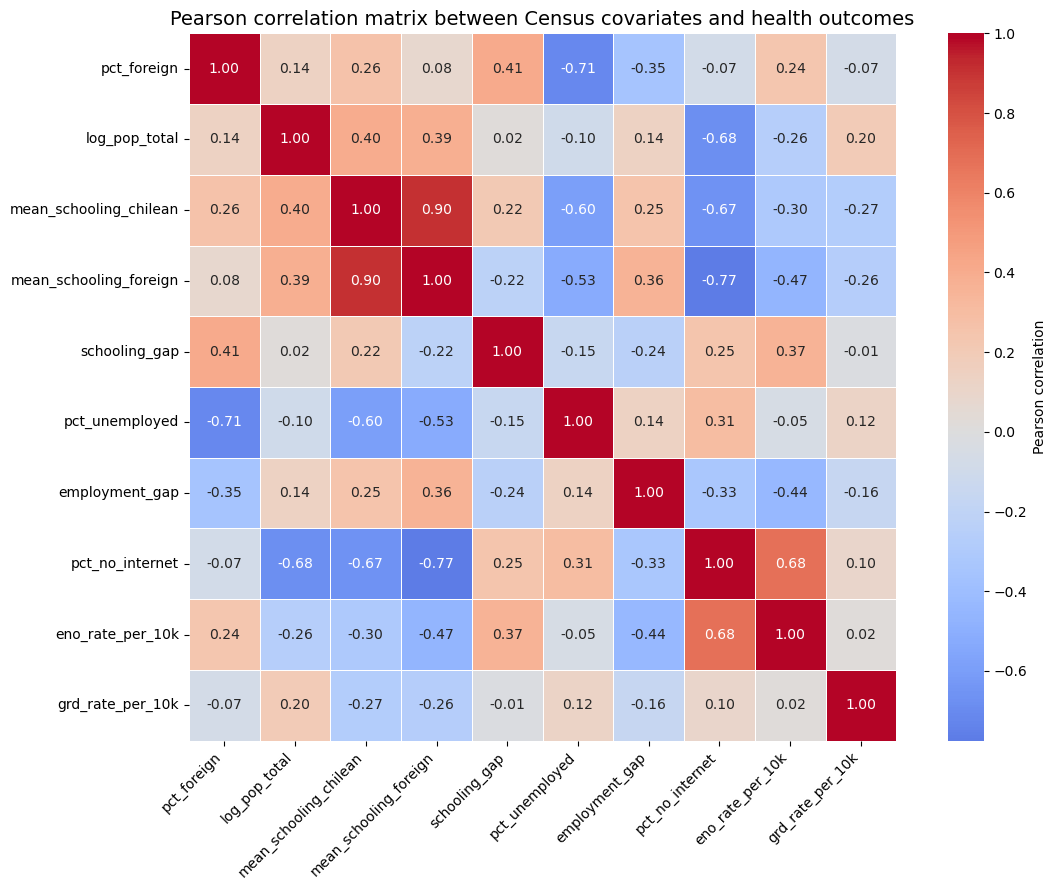


Tres correlaciones más fuertes de toda la matriz


,variable_1,variable_2,correlation,abs_correlation
23,mean_schooling_chilean,mean_schooling_foreign,0.903941,0.903941
37,mean_schooling_foreign,pct_no_internet,-0.774813,0.774813
5,pct_foreign,pct_unemployed,-0.708326,0.708326



Tres correlaciones más fuertes relacionadas con outcomes de salud


,variable_1,variable_2,correlation,abs_correlation
78,pct_no_internet,eno_rate_per_10k,0.680378,0.680378
38,mean_schooling_foreign,eno_rate_per_10k,-0.465632,0.465632
68,employment_gap,eno_rate_per_10k,-0.438105,0.438105


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

df_corr = analytical_table.copy()

# Variables seleccionadas
# Se ordenan por bloques para que el heatmap sea más fácil de leer
corr_vars = [
    # Demografía y tamaño
    "pct_foreign",
    "log_pop_total",
    
    # Educación
    "mean_schooling_chilean",
    "mean_schooling_foreign",
    "schooling_gap",
    
    # Empleo
    "pct_unemployed",
    "employment_gap",
    
    # Vivienda o servicios
    "pct_no_internet",
    
    # Outcomes de salud
    "eno_rate_per_10k",
    "grd_rate_per_10k"
]

# Verificar que todas las columnas existan
missing_cols = [col for col in corr_vars if col not in df_corr.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas para la matriz de correlación: {missing_cols}")

# Asegurar formato numérico
for col in corr_vars:
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")

# Matriz de correlación Pearson
corr_matrix = df_corr[corr_vars].corr(method="pearson")

print("Matriz de correlación Pearson")
display(corr_matrix.round(3))

# Heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Pearson correlation"}
)

plt.title(
    "Pearson correlation matrix between Census covariates and health outcomes",
    fontsize=14
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Top correlations for interpretation
# --------------------------------------------------

# Correlaciones más fuertes en toda la matriz, sin duplicados ni diagonal
corr_long = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_long.columns = ["variable_1", "variable_2", "correlation"]
corr_long["abs_correlation"] = corr_long["correlation"].abs()

top_3_overall = (
    corr_long
    .sort_values("abs_correlation", ascending=False)
    .head(3)
)

print("\nTres correlaciones más fuertes de toda la matriz")
display(top_3_overall)

# Correlaciones más fuertes que involucran outcomes de salud
health_outcomes = ["eno_rate_per_10k", "grd_rate_per_10k"]

top_health = (
    corr_long[
        corr_long["variable_1"].isin(health_outcomes) |
        corr_long["variable_2"].isin(health_outcomes)
    ]
    .sort_values("abs_correlation", ascending=False)
    .head(3)
)

print("\nTres correlaciones más fuertes relacionadas con outcomes de salud")
display(top_health)

The strongest correlations mainly appear between Census variables. The highest one is between mean_schooling_chilean and mean_schooling_foreign, around 0.90, which is expected because comunas with higher schooling levels among Chileans also tend to have higher schooling levels among foreigners.
Another strong relationship is between mean_schooling_foreign and pct_no_internet, around -0.77. This negative sign also makes sense, because comunas with higher schooling levels tend to have better access to services, including fixed internet. The third strong relationship is between pct_foreign and pct_unemployed, around -0.71. This sign is also plausible, since foreign-born residents may be more concentrated in working ages and active labor participation.
For the health outcomes, the clearest pattern is between pct_no_internet and eno_rate_per_10k, with a positive correlation around 0.68. This suggests that comunas with lower fixed internet access also tend to have higher ENO notification rates. In contrast, grd_rate_per_10k shows weaker correlations, so its relationship with the selected covariates is less clear.

### 1.2 Bivariate scatter plots

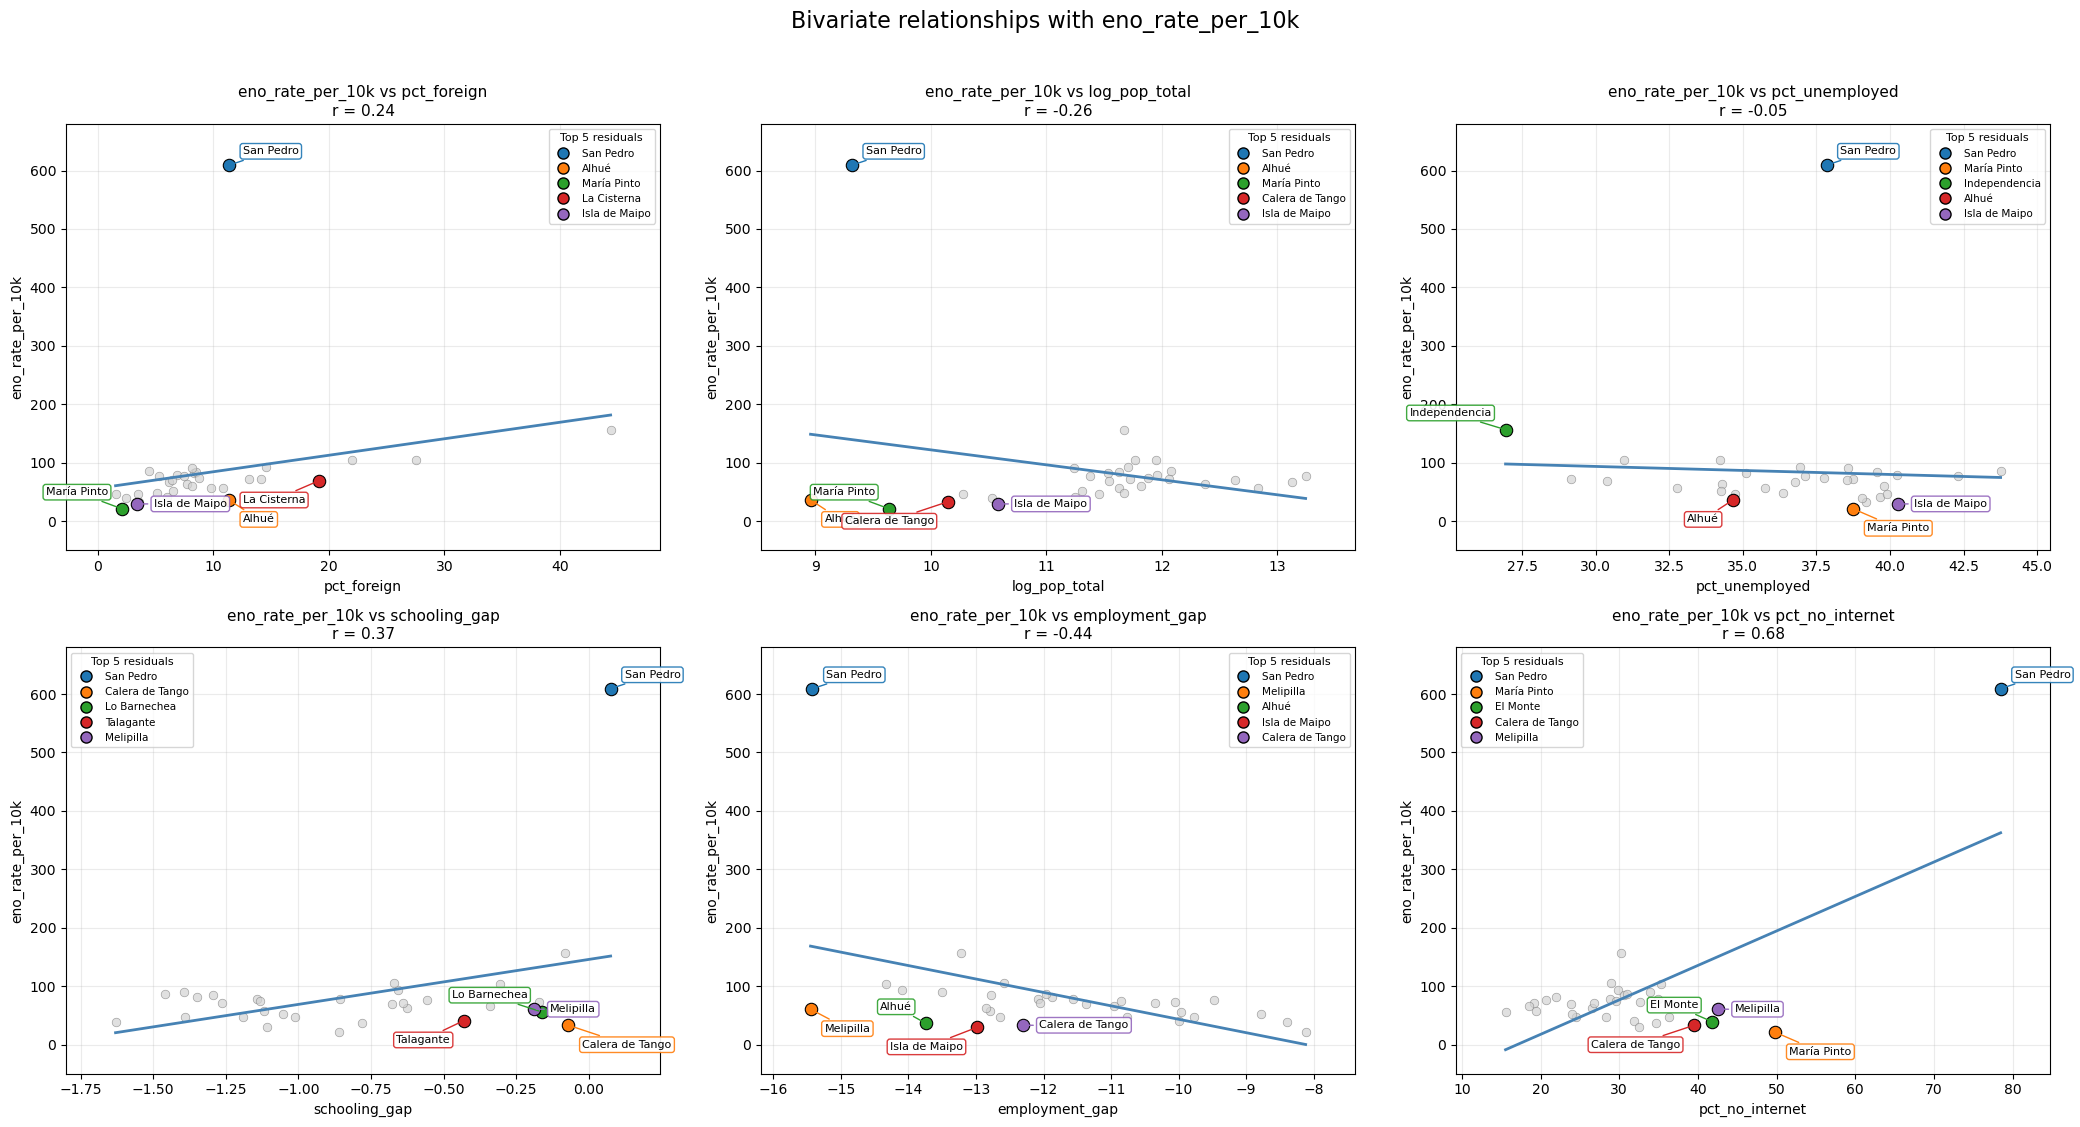

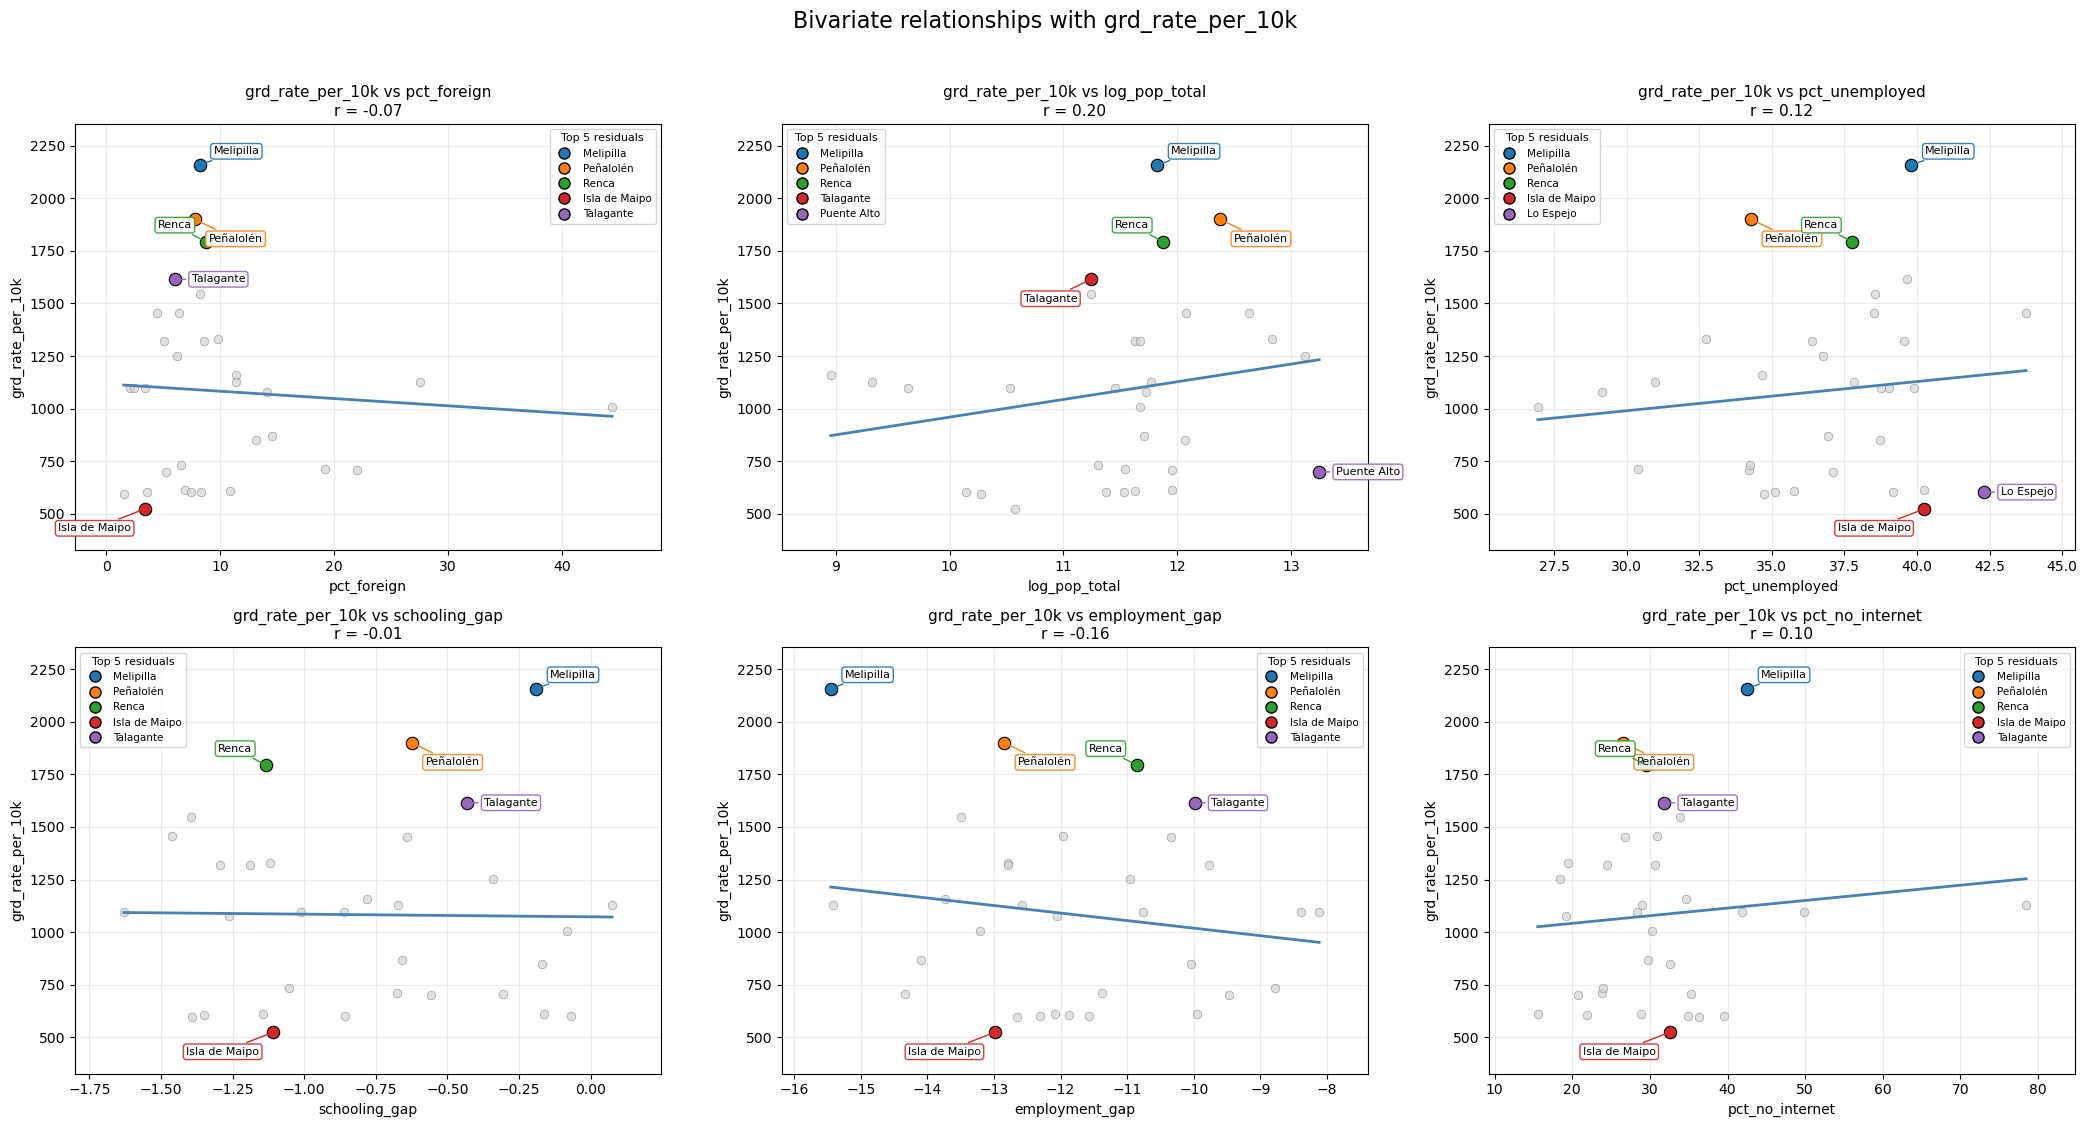

Comunas etiquetadas por residuos extremos en cada gráfico


,outcome,covariate,codigo_comuna,nombre_comuna,residual,abs_residual
20,eno_rate_per_10k,employment_gap,13505,San Pedro,441.382152,441.382152
21,eno_rate_per_10k,employment_gap,13501,Melipilla,-108.004605,108.004605
22,eno_rate_per_10k,employment_gap,13502,Alhué,-93.111504,93.111504
23,eno_rate_per_10k,employment_gap,13603,Isla de Maipo,-82.586824,82.586824
24,eno_rate_per_10k,employment_gap,13403,Calera de Tango,-63.349312,63.349312
5,eno_rate_per_10k,log_pop_total,13505,San Pedro,469.800043,469.800043
6,eno_rate_per_10k,log_pop_total,13502,Alhué,-112.493498,112.493498
7,eno_rate_per_10k,log_pop_total,13504,María Pinto,-110.224057,110.224057
8,eno_rate_per_10k,log_pop_total,13403,Calera de Tango,-85.111124,85.111124
9,eno_rate_per_10k,log_pop_total,13603,Isla de Maipo,-77.697529,77.697529


In [9]:
from matplotlib.lines import Line2D

plot_df = analytical_table.copy()

# Covariables del Census o derivadas desde Census
# Se incluye pct_no_internet como variable de vivienda/servicio
covariates = [
    "pct_foreign",
    "log_pop_total",
    "pct_unemployed",
    "schooling_gap",
    "employment_gap",
    "pct_no_internet"
]

# Outcomes de salud
health_outcomes = [
    "eno_rate_per_10k",
    "grd_rate_per_10k"
]

# Verificar columnas necesarias
needed_cols = ["codigo_comuna", "nombre_comuna"] + covariates + health_outcomes
missing_cols = [col for col in needed_cols if col not in plot_df.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas para 1.2: {missing_cols}")

# Asegurar formato numérico
for col in covariates + health_outcomes:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")


# --------------------------------------------------
# Función para obtener las 5 comunas con residuos más extremos
# --------------------------------------------------

def get_extreme_residuals(df, x_col, y_col, n_labels=5):
    temp = df[["codigo_comuna", "nombre_comuna", x_col, y_col]].dropna().copy()

    if len(temp) < 3:
        return temp.iloc[0:0].copy()

    slope, intercept = np.polyfit(temp[x_col], temp[y_col], 1)
    temp["predicted"] = intercept + slope * temp[x_col]
    temp["residual"] = temp[y_col] - temp["predicted"]
    temp["abs_residual"] = temp["residual"].abs()

    return temp.sort_values("abs_residual", ascending=False).head(n_labels).copy()


# --------------------------------------------------
# Función para dibujar cada panel
# --------------------------------------------------

def draw_panel(ax, df, x_col, y_col, n_labels=5):
    temp = df[["codigo_comuna", "nombre_comuna", x_col, y_col]].dropna().copy()

    # Puntos base
    ax.scatter(
        temp[x_col],
        temp[y_col],
        s=38,
        alpha=0.70,
        color="lightgray",
        edgecolor="gray",
        linewidth=0.5,
        zorder=1
    )

    # Línea OLS
    slope, intercept = np.polyfit(temp[x_col], temp[y_col], 1)
    x_line = np.linspace(temp[x_col].min(), temp[x_col].max(), 200)
    y_line = intercept + slope * x_line

    ax.plot(
        x_line,
        y_line,
        color="steelblue",
        linewidth=2,
        zorder=2
    )

    # Top 5 residuos extremos
    extreme = get_extreme_residuals(df, x_col, y_col, n_labels=n_labels)

    # Colores para comunas extremas
    palette = sns.color_palette("tab10", n_colors=n_labels)

    # Expandir un poco los límites para que no se corten nombres
    x_min, x_max = temp[x_col].min(), temp[x_col].max()
    y_min, y_max = temp[y_col].min(), temp[y_col].max()

    x_pad = (x_max - x_min) * 0.10 if x_max > x_min else 1
    y_pad = (y_max - y_min) * 0.12 if y_max > y_min else 1

    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    # Offsets manuales para evitar que los nombres se monten tanto
    offsets = [
        (10, 10),
        (10, -14),
        (-10, 12),
        (-10, -14),
        (12, 0)
    ]

    legend_elements = []

    for i, (_, row) in enumerate(extreme.iterrows()):
        comuna = row["nombre_comuna"]
        color = palette[i]

        # Punto destacado
        ax.scatter(
            row[x_col],
            row[y_col],
            s=80,
            color=color,
            edgecolor="black",
            linewidth=0.8,
            zorder=4
        )

        # Etiqueta
        dx, dy = offsets[i % len(offsets)]
        ha = "left" if dx > 0 else "right"

        ax.annotate(
            comuna,
            xy=(row[x_col], row[y_col]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=8,
            ha=ha,
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc="white",
                ec=color,
                alpha=0.90
            ),
            arrowprops=dict(
                arrowstyle="-",
                color=color,
                lw=1
            ),
            zorder=5
        )

        legend_elements.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=comuna,
                markerfacecolor=color,
                markeredgecolor="black",
                markersize=8
            )
        )

    # Correlación Pearson para el panel
    corr = temp[[x_col, y_col]].corr().iloc[0, 1]

    ax.set_title(f"{y_col} vs {x_col}\nr = {corr:.2f}", fontsize=11)
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_ylabel(y_col, fontsize=10)
    ax.grid(alpha=0.25)

    # Leyenda por panel
    ax.legend(
        handles=legend_elements,
        title="Top 5 residuals",
        loc="best",
        fontsize=7.5,
        title_fontsize=8,
        frameon=True
    )

    return extreme


# --------------------------------------------------
# Crear figuras
# --------------------------------------------------

all_extreme_residuals = []

for outcome in health_outcomes:
    fig, axes = plt.subplots(2, 3, figsize=(21, 11))
    axes = axes.flatten()

    for i, covariate in enumerate(covariates):
        ax = axes[i]

        extreme = draw_panel(
            ax=ax,
            df=plot_df,
            x_col=covariate,
            y_col=outcome,
            n_labels=5
        )

        extreme["outcome"] = outcome
        extreme["covariate"] = covariate
        all_extreme_residuals.append(extreme)

    fig.suptitle(
        f"Bivariate relationships with {outcome}",
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Tabla resumen de comunas etiquetadas
# --------------------------------------------------

extreme_residuals_table = pd.concat(all_extreme_residuals, ignore_index=True)

extreme_residuals_table = extreme_residuals_table[
    [
        "outcome",
        "covariate",
        "codigo_comuna",
        "nombre_comuna",
        "residual",
        "abs_residual"
    ]
].sort_values(
    ["outcome", "covariate", "abs_residual"],
    ascending=[True, True, False]
)

print("Comunas etiquetadas por residuos extremos en cada gráfico")
display(extreme_residuals_table)

In the bivariate graphs, San Pedro is the most extreme commune for eno_rate_per_10k, as it has a much higher notification rate than the other communes. This causes it to appear as an outlier in several panels, regardless of the census covariate used.
For grd_rate_per_10k, the commune that stands out the most is Melipilla, with the highest rate of DRG discharges per 10,000 inhabitants. High values ​​are also observed in communes such as Peñalolén and Renca, although Melipilla appears as the most extreme point.

In general, the graphs serve to identify communes that deviate from the pattern expected by the OLS line, but these relationships should be interpreted as exploratory associations and not as causal evidence.

### 1.3 Outlier and leverage discussion

San Pedro appears as an outlier in the eno_rate_per_10k, as it has a higher rate of reported notifiable diseases than the other municipalities. One possible explanation is that its sociodemographic profile differs from that of more urban municipalities in the Metropolitan Region. If the municipality has a foreign population linked to agricultural, seasonal, or other jobs requiring greater territorial exposure, there could be conditions that increase the risk of certain notifiable diseases or generate a higher concentration of cases in specific groups. Also, this may also be related to its more rural and peripheral profile compared with more urban comunas in the Metropolitan Region.

Melipilla stands out as an outlier in the grd_rate_per_10k graphs because it has a higher DRG discharge rate than the other municipalities. One possible explanation is that the municipality serves as a key hospital care center for the Melipilla Province, especially due to the presence of the San José de Melipilla Hospital. This hospital not only serves the population of Melipilla but can also receive patients from nearby municipalities such as San Pedro, María Pinto, Alhué, and Curacaví. Therefore, part of its high rate could be associated with a hospital burden that exceeds the number of residents of the municipality. In this case, Melipilla acts as an extreme point that can affect the OLS line, so it should be interpreted with caution. Also, like before, this may also be related to its more rural and peripheral profile compared with more urban comunas in the Metropolitan Region.

## Part 2: Count-Data Regression (2.5 pts)

### 2.1 Poisson regression (0.75 pts)

In [10]:
import statsmodels.api as sm

poisson_df = analytical_table.copy()

# --------------------------------------------------
# Variables del modelo
# --------------------------------------------------

outcome = "eno_total"

covariates = [
    "pct_foreign",       # composición extranjera
    "schooling_gap",     # educación
    "employment_gap",    # empleo
    "pct_no_internet"    # vivienda / servicios
]

required_cols = [
    "codigo_comuna",
    "nombre_comuna",
    "pop_total",
    outcome
] + covariates

missing_cols = [col for col in required_cols if col not in poisson_df.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas para el modelo Poisson: {missing_cols}")

# --------------------------------------------------
# Preparar datos
# --------------------------------------------------

for col in ["pop_total", outcome] + covariates:
    poisson_df[col] = pd.to_numeric(poisson_df[col], errors="coerce")

# El modelo solo usa filas completas
poisson_data = poisson_df[required_cols].dropna().copy()

# Validaciones básicas
if (poisson_data["pop_total"] <= 0).any():
    raise ValueError("Hay comunas con pop_total <= 0. No se puede usar log(pop_total) como offset.")

if (poisson_data[outcome] < 0).any():
    raise ValueError("Hay comunas con eno_total negativo. Revisa los datos.")

print("N usado en el modelo Poisson:", len(poisson_data))
print("Filas eliminadas por valores nulos:", len(poisson_df) - len(poisson_data))

print("\nCovariables usadas en el modelo:")
for var in covariates:
    print("-", var)

# --------------------------------------------------
# Ajustar modelo Poisson con offset poblacional
# --------------------------------------------------

X = poisson_data[covariates]
X = sm.add_constant(X)

y = poisson_data[outcome]

offset = np.log(poisson_data["pop_total"])

poisson_eno_model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson(),
    offset=offset
).fit()

# --------------------------------------------------
# Tabla completa de coeficientes
# --------------------------------------------------

coef_table = pd.DataFrame({
    "coef": poisson_eno_model.params,
    "std_error": poisson_eno_model.bse,
    "z_value": poisson_eno_model.tvalues,
    "p_value": poisson_eno_model.pvalues
})

print("\nPoisson coefficient table")
display(coef_table)

# --------------------------------------------------
# Incidence Rate Ratios con IC 95%
# --------------------------------------------------

conf_int = poisson_eno_model.conf_int()
conf_int.columns = ["coef_ci_lower", "coef_ci_upper"]

irr_table = pd.DataFrame({
    "coef": poisson_eno_model.params,
    "IRR": np.exp(poisson_eno_model.params),
    "IRR_95CI_lower": np.exp(conf_int["coef_ci_lower"]),
    "IRR_95CI_upper": np.exp(conf_int["coef_ci_upper"]),
    "p_value": poisson_eno_model.pvalues
})

print("\nIncidence Rate Ratios")
display(irr_table)

# --------------------------------------------------
# Métricas de ajuste del modelo
# --------------------------------------------------

fit_stats = pd.DataFrame({
    "metric": [
        "deviance",
        "pearson_chi2",
        "AIC",
        "df_model",
        "df_resid"
    ],
    "value": [
        poisson_eno_model.deviance,
        poisson_eno_model.pearson_chi2,
        poisson_eno_model.aic,
        poisson_eno_model.df_model,
        poisson_eno_model.df_resid
    ]
})

print("\nModel fit statistics")
display(fit_stats)

# --------------------------------------------------
# Guardar tablas para las siguientes partes
# --------------------------------------------------

poisson_eno_coef_table = coef_table.copy()
poisson_eno_irr_table = irr_table.copy()
poisson_eno_fit_stats = fit_stats.copy()

print("\nModelo Poisson para ENO ajustado correctamente.")

N usado en el modelo Poisson: 32
Filas eliminadas por valores nulos: 0

Covariables usadas en el modelo:
- pct_foreign
- schooling_gap
- employment_gap
- pct_no_internet

Poisson coefficient table


,coef,std_error,z_value,p_value
const,-5.694880,0.040139,-141.877876,0.000000e+00
pct_foreign,0.016821,0.000679,24.769514,1.910846e-135
schooling_gap,0.070246,0.014258,4.926792,8.359047e-07
employment_gap,-0.011519,0.003945,-2.919762,3.502986e-03
pct_no_internet,0.019731,0.000777,25.401856,2.405537e-142



Incidence Rate Ratios


,coef,IRR,IRR_95CI_lower,IRR_95CI_upper,p_value
const,-5.694880,0.003363,0.003109,0.003638,0.000000e+00
pct_foreign,0.016821,1.016963,1.015610,1.018317,1.910846e-135
schooling_gap,0.070246,1.072772,1.043208,1.103173,8.359047e-07
employment_gap,-0.011519,0.988547,0.980933,0.996221,3.502986e-03
pct_no_internet,0.019731,1.019926,1.018375,1.021480,2.405537e-142



Model fit statistics


,metric,value
0,deviance,2380.545174
1,pearson_chi2,2495.058857
2,AIC,2655.860610
3,df_model,4.000000
4,df_resid,27.000000



Modelo Poisson para ENO ajustado correctamente.


The Poisson model suggests that pct_foreign, schooling_gap, and pct_no_internet are positively associated with the expected ENO notification rate, while employment_gap shows a negative association. In IRR terms, higher foreign population share and higher lack of fixed internet access are associated with higher expected ENO rates, holding the other variables constant.
However, the model fit statistics suggest strong overdispersion, since the Pearson chi-square is very large compared with the residual degrees of freedom. Therefore, the Poisson results should be interpreted cautiously, and a Negative Binomial model is needed to check whether the conclusions remain stable.

### 2.2 Check for overdispersion (0.5 pts)

In [11]:
pearson_chi2 = poisson_eno_model.pearson_chi2
df_resid = poisson_eno_model.df_resid

dispersion_stat = pearson_chi2 / df_resid

overdispersion_table = pd.DataFrame({
    "metric": [
        "Pearson chi-square",
        "Residual degrees of freedom",
        "Dispersion statistic"
    ],
    "value": [
        pearson_chi2,
        df_resid,
        dispersion_stat
    ]
})

print("Overdispersion check")
display(overdispersion_table)

# Interpretación automática
if dispersion_stat <= 1.5:
    interpretation = "No strong evidence of overdispersion."
elif dispersion_stat <= 3:
    interpretation = "Moderate overdispersion is present."
else:
    interpretation = "Strong overdispersion is present."

print("\nInterpretation:")
print(interpretation)

Overdispersion check


,metric,value
0,Pearson chi-square,2495.058857
1,Residual degrees of freedom,27.000000
2,Dispersion statistic,92.409587



Interpretation:
Strong overdispersion is present.


The dispersion value was 92.41, much higher than expected. This demonstrates that ENO counts vary much more than the Poisson model predicts. This means that the results of the Poisson model must be interpreted with caution.

### 2.3 Negative Binomial regression (0.75 pts)

In [12]:
nb_df = analytical_table.copy()

# Mismo outcome y mismas covariables que en el modelo Poisson
outcome = "eno_total"

covariates = [
    "pct_foreign",
    "schooling_gap",
    "employment_gap",
    "pct_no_internet"
]

required_cols = [
    "codigo_comuna",
    "nombre_comuna",
    "pop_total",
    outcome
] + covariates

missing_cols = [col for col in required_cols if col not in nb_df.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas para el modelo Negative Binomial: {missing_cols}")

# Convertir a numérico
for col in ["pop_total", outcome] + covariates:
    nb_df[col] = pd.to_numeric(nb_df[col], errors="coerce")

# Filas completas
nb_data = nb_df[required_cols].dropna().copy()

if (nb_data["pop_total"] <= 0).any():
    raise ValueError("Hay comunas con pop_total <= 0. No se puede usar log(pop_total) como offset.")

if (nb_data[outcome] < 0).any():
    raise ValueError("Hay comunas con eno_total negativo. Revisa los datos.")

print("N usado en el modelo Negative Binomial:", len(nb_data))
print("Filas eliminadas por valores nulos:", len(nb_df) - len(nb_data))

# Matriz de covariables
X_nb = nb_data[covariates]
X_nb = sm.add_constant(X_nb)

y_nb = nb_data[outcome]

offset_nb = np.log(nb_data["pop_total"])

# --------------------------------------------------
# Ajustar modelo Negative Binomial
# --------------------------------------------------

nb_eno_model = sm.NegativeBinomial(
    y_nb,
    X_nb,
    offset=offset_nb
).fit(disp=False, maxiter=1000)

print("\nNegative Binomial model fitted correctly.")

# --------------------------------------------------
# Tabla de coeficientes Negative Binomial
# --------------------------------------------------

nb_coef_table = pd.DataFrame({
    "coef": nb_eno_model.params,
    "std_error": nb_eno_model.bse,
    "z_value": nb_eno_model.tvalues,
    "p_value": nb_eno_model.pvalues
})

print("\nNegative Binomial coefficient table")
display(nb_coef_table)

# --------------------------------------------------
# Comparación Poisson vs Negative Binomial
# Se excluye alpha porque es el parámetro de dispersión del modelo NB
# --------------------------------------------------

comparison_vars = ["const"] + covariates

comparison_table = pd.DataFrame({
    "poisson_coef": poisson_eno_model.params[comparison_vars],
    "poisson_p_value": poisson_eno_model.pvalues[comparison_vars],
    "nb_coef": nb_eno_model.params[comparison_vars],
    "nb_p_value": nb_eno_model.pvalues[comparison_vars]
})

comparison_table["poisson_significant_5pct"] = comparison_table["poisson_p_value"] < 0.05
comparison_table["nb_significant_5pct"] = comparison_table["nb_p_value"] < 0.05
comparison_table["changed_conclusion"] = (
    comparison_table["poisson_significant_5pct"] !=
    comparison_table["nb_significant_5pct"]
)

print("\nPoisson vs Negative Binomial comparison")
display(comparison_table)

# --------------------------------------------------
# IRR para Negative Binomial
# --------------------------------------------------

nb_conf_int = nb_eno_model.conf_int()
nb_conf_int.columns = ["coef_ci_lower", "coef_ci_upper"]

nb_irr_table = pd.DataFrame({
    "coef": nb_eno_model.params,
    "IRR": np.exp(nb_eno_model.params),
    "IRR_95CI_lower": np.exp(nb_conf_int["coef_ci_lower"]),
    "IRR_95CI_upper": np.exp(nb_conf_int["coef_ci_upper"]),
    "p_value": nb_eno_model.pvalues
})

print("\nNegative Binomial Incidence Rate Ratios")
display(nb_irr_table.loc[comparison_vars])

# --------------------------------------------------
# Métricas de ajuste
# --------------------------------------------------

model_fit_comparison = pd.DataFrame({
    "model": ["Poisson", "Negative Binomial"],
    "AIC": [poisson_eno_model.aic, nb_eno_model.aic],
    "LogLik": [poisson_eno_model.llf, nb_eno_model.llf]
})

print("\nModel fit comparison")
display(model_fit_comparison)

# --------------------------------------------------
# Coeficientes que cambian conclusión
# --------------------------------------------------

changed = comparison_table[comparison_table["changed_conclusion"]].copy()

print("\nCoefficients whose 5% significance conclusion changed")
if changed.empty:
    print("No coefficients changed their significance conclusion at the 5% level.")
else:
    display(changed)

# Guardar resultados para pasos posteriores
nb_eno_coef_table = nb_coef_table.copy()
nb_eno_comparison_table = comparison_table.copy()
nb_eno_irr_table = nb_irr_table.copy()
nb_eno_fit_comparison = model_fit_comparison.copy()

N usado en el modelo Negative Binomial: 32
Filas eliminadas por valores nulos: 0

Negative Binomial model fitted correctly.

Negative Binomial coefficient table


c:\Users\benja\miniconda3\envs\Datos\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


,coef,std_error,z_value,p_value
const,-6.829247,0.522851,-13.061566,5.459341e-39
pct_foreign,0.021707,0.011397,1.904628,5.682841e-02
schooling_gap,0.105751,0.175503,0.602559,5.468020e-01
employment_gap,-0.095014,0.052015,-1.826655,6.775169e-02
pct_no_internet,0.020941,0.006801,3.079203,2.075553e-03
alpha,0.160292,0.040584,3.949647,7.826645e-05



Poisson vs Negative Binomial comparison


,poisson_coef,poisson_p_value,nb_coef,nb_p_value,poisson_significant_5pct,nb_significant_5pct,changed_conclusion
const,-5.694880,0.000000e+00,-6.829247,5.459341e-39,True,True,False
pct_foreign,0.016821,1.910846e-135,0.021707,5.682841e-02,True,False,True
schooling_gap,0.070246,8.359047e-07,0.105751,5.468020e-01,True,False,True
employment_gap,-0.011519,3.502986e-03,-0.095014,6.775169e-02,True,False,True
pct_no_internet,0.019731,2.405537e-142,0.020941,2.075553e-03,True,True,False


...

,coef,IRR,IRR_95CI_lower,IRR_95CI_upper,p_value
const,-6.829247,0.001082,0.000388,0.003014,5.459341e-39
pct_foreign,0.021707,1.021944,0.999370,1.045029,5.682841e-02
schooling_gap,0.105751,1.111545,0.788022,1.567890,5.468020e-01
employment_gap,-0.095014,0.909360,0.821221,1.006958,6.775169e-02
pct_no_internet,0.020941,1.021161,1.007641,1.034864,2.075553e-03



Model fit comparison


,model,AIC,LogLik
0,Poisson,2655.860610,-1322.930305
1,Negative Binomial,460.252845,-224.126423



Coefficients whose 5% significance conclusion changed


,poisson_coef,poisson_p_value,nb_coef,nb_p_value,poisson_significant_5pct,nb_significant_5pct,changed_conclusion
pct_foreign,0.016821,1.910846e-135,0.021707,0.056828,True,False,True
schooling_gap,0.070246,8.359047e-07,0.105751,0.546802,True,False,True
employment_gap,-0.011519,3.502986e-03,-0.095014,0.067752,True,False,True


Compared to the Poisson model, several changes in the results were observed. The variables pct_foreign, schooling_gap, and employment_gap were significant in the Poisson model, but ceased to be significant at the 5% level in the negative binomial model. In contrast, pct_no_internet remained significant, suggesting that the percentage of households without fixed internet access is the most stable predictor in this model.
The model fit also improved markedly, with the AIC decreasing from 2655.86 in the Poisson model to 460.25 in the negative binomial model, where a lower value indicates better performance. Therefore, we conclude that the negative binomial model is a better primary model for ENO.

### 2.4 Repeat for GRD (0.5 pts)

In [13]:
grd_df = analytical_table.copy()

# Outcome y mismas covariables usadas en ENO
outcome = "grd_total"

covariates = [
    "pct_foreign",
    "schooling_gap",
    "employment_gap",
    "pct_no_internet"
]

required_cols = [
    "codigo_comuna",
    "nombre_comuna",
    "pop_total",
    outcome
] + covariates

missing_cols = [col for col in required_cols if col not in grd_df.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas para el modelo GRD: {missing_cols}")

# --------------------------------------------------
# Preparar datos
# --------------------------------------------------

for col in ["pop_total", outcome] + covariates:
    grd_df[col] = pd.to_numeric(grd_df[col], errors="coerce")

grd_data = grd_df[required_cols].dropna().copy()

if (grd_data["pop_total"] <= 0).any():
    raise ValueError("Hay comunas con pop_total <= 0. No se puede usar log(pop_total) como offset.")

if (grd_data[outcome] < 0).any():
    raise ValueError("Hay comunas con grd_total negativo. Revisa los datos.")

print("N usado en modelos GRD:", len(grd_data))
print("Filas eliminadas por valores nulos:", len(grd_df) - len(grd_data))

# Matriz de covariables
X_grd = sm.add_constant(grd_data[covariates])
y_grd = grd_data[outcome]
offset_grd = np.log(grd_data["pop_total"])

# --------------------------------------------------
# Modelo Poisson
# --------------------------------------------------

poisson_grd_model = sm.GLM(
    y_grd,
    X_grd,
    family=sm.families.Poisson(),
    offset=offset_grd
).fit()

poisson_grd_dispersion = poisson_grd_model.pearson_chi2 / poisson_grd_model.df_resid

print("\nPoisson GRD dispersion statistic")
print(poisson_grd_dispersion)

# --------------------------------------------------
# Modelo Negative Binomial
# --------------------------------------------------

nb_grd_model = sm.NegativeBinomial(
    y_grd,
    X_grd,
    offset=offset_grd
).fit(disp=False, maxiter=1000)

print("\nNegative Binomial GRD fitted correctly.")

# --------------------------------------------------
# Tabla comparativa Poisson vs Negative Binomial
# --------------------------------------------------

comparison_vars = ["const"] + covariates

grd_model_comparison = pd.DataFrame({
    "poisson_coef": poisson_grd_model.params[comparison_vars],
    "poisson_p_value": poisson_grd_model.pvalues[comparison_vars],
    "nb_coef": nb_grd_model.params[comparison_vars],
    "nb_p_value": nb_grd_model.pvalues[comparison_vars]
})

grd_model_comparison["poisson_significant_5pct"] = grd_model_comparison["poisson_p_value"] < 0.05
grd_model_comparison["nb_significant_5pct"] = grd_model_comparison["nb_p_value"] < 0.05
grd_model_comparison["changed_conclusion"] = (
    grd_model_comparison["poisson_significant_5pct"] !=
    grd_model_comparison["nb_significant_5pct"]
)

print("\nPoisson vs Negative Binomial coefficient comparison for GRD")
display(grd_model_comparison)

# --------------------------------------------------
# Comparación de ajuste
# --------------------------------------------------

grd_fit_comparison = pd.DataFrame({
    "model": ["Poisson", "Negative Binomial"],
    "AIC": [poisson_grd_model.aic, nb_grd_model.aic],
    "LogLik": [poisson_grd_model.llf, nb_grd_model.llf],
    "dispersion_statistic": [poisson_grd_dispersion, np.nan]
})

print("\nModel fit comparison for GRD")
display(grd_fit_comparison)

# --------------------------------------------------
# Elegir modelo preferido
# --------------------------------------------------

if (poisson_grd_dispersion > 1.5) and (nb_grd_model.aic < poisson_grd_model.aic):
    preferred_grd_model_name = "Negative Binomial"
    preferred_grd_model = nb_grd_model
else:
    preferred_grd_model_name = "Poisson"
    preferred_grd_model = poisson_grd_model

print("\nPreferred model for GRD:")
print(preferred_grd_model_name)

# --------------------------------------------------
# IRR del modelo preferido
# --------------------------------------------------

conf_int = preferred_grd_model.conf_int()
conf_int.columns = ["coef_ci_lower", "coef_ci_upper"]

preferred_params = preferred_grd_model.params
preferred_pvalues = preferred_grd_model.pvalues

# Excluir alpha si el modelo Negative Binomial lo incluye
irr_vars = [var for var in preferred_params.index if var != "alpha"]

grd_irr_table = pd.DataFrame({
    "coef": preferred_params[irr_vars],
    "IRR": np.exp(preferred_params[irr_vars]),
    "IRR_95CI_lower": np.exp(conf_int.loc[irr_vars, "coef_ci_lower"]),
    "IRR_95CI_upper": np.exp(conf_int.loc[irr_vars, "coef_ci_upper"]),
    "p_value": preferred_pvalues[irr_vars]
})

print("\nIRR table for preferred GRD model")
display(grd_irr_table)

# --------------------------------------------------
# Identificar el efecto más grande entre covariables
# --------------------------------------------------

effect_table = grd_irr_table.loc[covariates].copy()
effect_table["distance_from_1"] = (effect_table["IRR"] - 1).abs()

largest_effect_var = effect_table["distance_from_1"].idxmax()
largest_effect = effect_table.loc[largest_effect_var]

print("\nLargest effect among covariates")
print("Variable:", largest_effect_var)
print("IRR:", largest_effect["IRR"])
print("p-value:", largest_effect["p_value"])

# Guardar objetos para partes posteriores
poisson_grd_fit = poisson_grd_model
nb_grd_fit = nb_grd_model
grd_model_comparison_table = grd_model_comparison.copy()
grd_fit_comparison_table = grd_fit_comparison.copy()
grd_preferred_model = preferred_grd_model
grd_preferred_model_name = preferred_grd_model_name
grd_preferred_irr_table = grd_irr_table.copy()

N usado en modelos GRD: 32
Filas eliminadas por valores nulos: 0

Poisson GRD dispersion statistic
1886.7515223454664

Negative Binomial GRD fitted correctly.

Poisson vs Negative Binomial coefficient comparison for GRD


c:\Users\benja\miniconda3\envs\Datos\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


,poisson_coef,poisson_p_value,nb_coef,nb_p_value,poisson_significant_5pct,nb_significant_5pct,changed_conclusion
const,-3.258550,0.000000e+00,-2.795041,1.411223e-08,True,True,False
pct_foreign,-0.018069,0.000000e+00,-0.007239,4.376670e-01,True,False,True
schooling_gap,0.039945,7.846738e-30,-0.019986,9.022083e-01,True,False,True
employment_gap,-0.105962,0.000000e+00,-0.047314,2.304436e-01,True,False,True
pct_no_internet,0.002147,2.530889e-24,0.002109,7.523871e-01,True,False,True



Model fit comparison for GRD


,model,AIC,LogLik,dispersion_statistic
0,Poisson,53582.345748,-26786.172874,1886.751522
1,Negative Binomial,627.990774,-307.995387,NaN



Preferred model for GRD:
Negative Binomial

IRR table for preferred GRD model


,coef,IRR,IRR_95CI_lower,IRR_95CI_upper,p_value
const,-2.795041,0.061112,0.023264,0.160539,1.411223e-08
pct_foreign,-0.007239,0.992787,0.974802,1.011103,4.376670e-01
schooling_gap,-0.019986,0.980212,0.712629,1.348268,9.022083e-01
employment_gap,-0.047314,0.953788,0.882813,1.030469,2.304436e-01
pct_no_internet,0.002109,1.002111,0.989066,1.015329,7.523871e-01



Largest effect among covariates
Variable: employment_gap
IRR: 0.9537880420371966
p-value: 0.23044362714290123


After analyzing the two models for grd_total, the Negative Binomial model was preferred over the Poisson model. The main reason is that the Poisson model showed a very high dispersion value of 1886.75, meaning that the GRD counts vary much more than what a Poisson model can properly handle.
The model comparison also supports this choice. The Poisson model had an AIC of 53582.35, while the Negative Binomial model had a much lower AIC of 627.99. Since a lower AIC indicates a better fit, the Negative Binomial model fits the GRD data much better.
In the Poisson model, all covariates appeared significant. However, after using the Negative Binomial model, none of them remained significant at the 5% level. This suggests that the Poisson model was likely overstating the strength of the effects. The largest effect in the preferred GRD model was observed for employment_gap, with an IRR of about 0.954. This suggests that a one-point increase in employment_gap is associated with a lower expected GRD rate, but since the effect was not statistically significant, it should only be interpreted as a weak descriptive pattern.

## Part 3: Continuous-Outcome Regression (1.5 pts)

### 3.1 Pick an outcome

As a group, we chose grd_mortality_rate as the continuous outcome for this section. We were interested in this variable because it provides the mortality rate associated with hospital discharges by DRG at the commune level, making it a more robust health indicator than simply considering the number of discharges, the average length of stay, or any other factor.
This outcome can help us explore whether the demographic and socioeconomic characteristics of communes are associated with differences in hospital mortality. However, the results should be interpreted with caution, as mortality rates can be unstable when the number of cases is small.

One of the questions that can be asked, and which prompted our choice of this variable, is: Are commune characteristics associated with higher hospital mortality?

### 3.2 Linear regression

In [14]:
ols_df = analytical_table.copy()

# Outcome elegido en 3.1
outcome = "grd_mortality_rate"

# Mismas covariables usadas en la Parte 2
covariates = [
    "pct_foreign",
    "schooling_gap",
    "employment_gap",
    "pct_no_internet"
]

required_cols = [
    "codigo_comuna",
    "nombre_comuna",
    outcome
] + covariates

missing_cols = [col for col in required_cols if col not in ols_df.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas para la regresión lineal: {missing_cols}")

# Convertir variables a formato numérico
for col in [outcome] + covariates:
    ols_df[col] = pd.to_numeric(ols_df[col], errors="coerce")

# Usar solo filas completas
ols_data = ols_df[required_cols].dropna().copy()

print("N usado en la regresión OLS:", len(ols_data))
print("Filas eliminadas por valores nulos:", len(ols_df) - len(ols_data))

print("\nRango del outcome seleccionado:")
print("Mínimo:", ols_data[outcome].min())
print("Máximo:", ols_data[outcome].max())

# --------------------------------------------------
# Ajustar modelo OLS
# --------------------------------------------------

X = ols_data[covariates]
X = sm.add_constant(X)

y = ols_data[outcome]

ols_mortality_model = sm.OLS(y, X).fit()

# --------------------------------------------------
# Tabla de coeficientes
# --------------------------------------------------

ols_coef_table = pd.DataFrame({
    "coef": ols_mortality_model.params,
    "std_error": ols_mortality_model.bse,
    "t_value": ols_mortality_model.tvalues,
    "p_value": ols_mortality_model.pvalues
})

print("\nOLS coefficient table")
display(ols_coef_table)

# --------------------------------------------------
# R² y R² ajustado
# --------------------------------------------------

ols_fit_stats = pd.DataFrame({
    "metric": [
        "R_squared",
        "Adjusted_R_squared",
        "AIC",
        "BIC"
    ],
    "value": [
        ols_mortality_model.rsquared,
        ols_mortality_model.rsquared_adj,
        ols_mortality_model.aic,
        ols_mortality_model.bic
    ]
})

print("\nOLS fit statistics")
display(ols_fit_stats)

# --------------------------------------------------
# Predicciones y residuos para diagnóstico posterior
# --------------------------------------------------

ols_data["fitted_values"] = ols_mortality_model.fittedvalues
ols_data["residuals"] = ols_mortality_model.resid

print("\nPrimeras filas con valores ajustados y residuos")
display(
    ols_data[
        [
            "codigo_comuna",
            "nombre_comuna",
            outcome,
            "fitted_values",
            "residuals"
        ]
    ].sort_values("residuals", key=abs, ascending=False).head()
)

# Guardar objetos para 3.3
ols_mortality_data = ols_data.copy()
ols_mortality_coef_table = ols_coef_table.copy()
ols_mortality_fit_stats = ols_fit_stats.copy()

print("\nModelo OLS para grd_mortality_rate ajustado correctamente.")

N usado en la regresión OLS: 32
Filas eliminadas por valores nulos: 0

Rango del outcome seleccionado:
Mínimo: 0.0331779544831368
Máximo: 3.49

OLS coefficient table


,coef,std_error,t_value,p_value
const,2.480029,1.216009,2.039482,0.051298
pct_foreign,-0.024872,0.023716,-1.048742,0.303594
schooling_gap,-0.098066,0.406446,-0.241278,0.811163
employment_gap,-0.044027,0.102581,-0.429194,0.671188
pct_no_internet,-0.017511,0.016605,-1.054548,0.300978



OLS fit statistics


,metric,value
0,R_squared,0.089762
1,Adjusted_R_squared,-0.045088
2,AIC,91.264969
3,BIC,98.593648



Primeras filas con valores ajustados y residuos


,codigo_comuna,nombre_comuna,grd_mortality_rate,fitted_values,residuals
0,13104,Conchalí,0.036834,2.282106,-2.245273
4,13109,La Cisterna,0.037885,2.153120,-2.115235
13,13126,Quinta Normal,0.033178,1.907830,-1.874652
3,13108,Independencia,2.856332,1.436206,1.420126
14,13127,Recoleta,2.977298,1.976648,1.000650



Modelo OLS para grd_mortality_rate ajustado correctamente.


The OLS model was fitted using the DRG mortality rate as the response variable and the same covariates used in Part 2: percentage of foreigners, education gap, employment gap, and percentage of people without internet access. The model included 32 municipalities, and no rows were removed due to missing values.
The results show that none of the covariates were statistically significant at the 5% level. The model also presented a low R² of 0.090 and a negative adjusted R², indicating that these covariates explain only a small portion of the variation in DRG mortality rates among the municipalities. Therefore, the relationship between the selected municipality-level characteristics and hospital mortality appears weak in this linear model.

### 3.3 Diagnostics

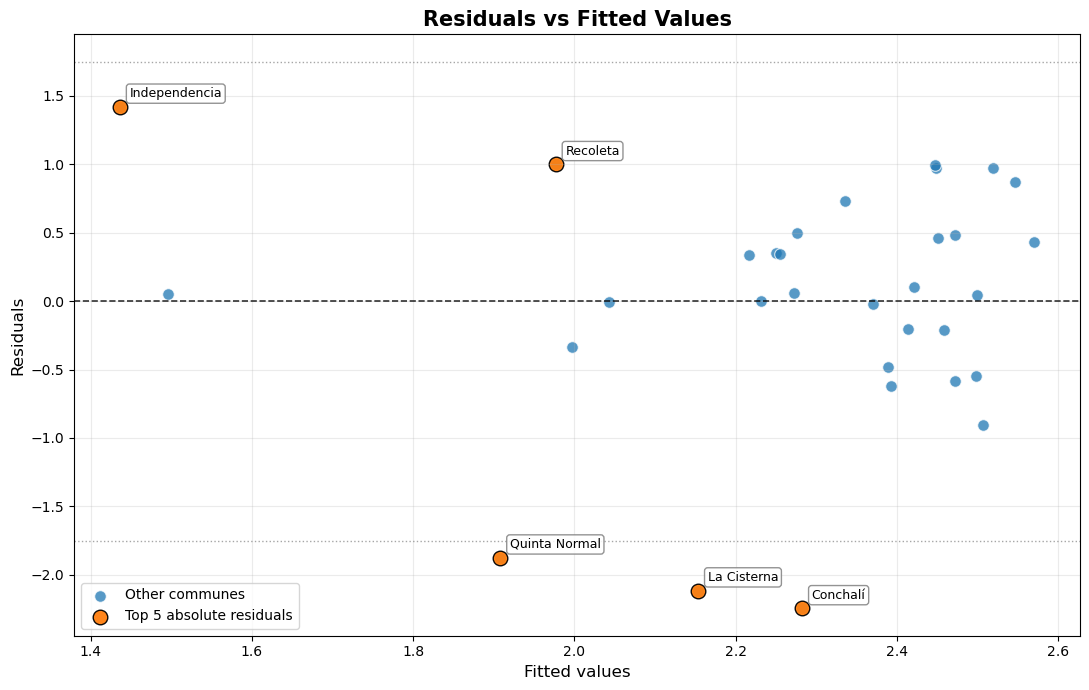

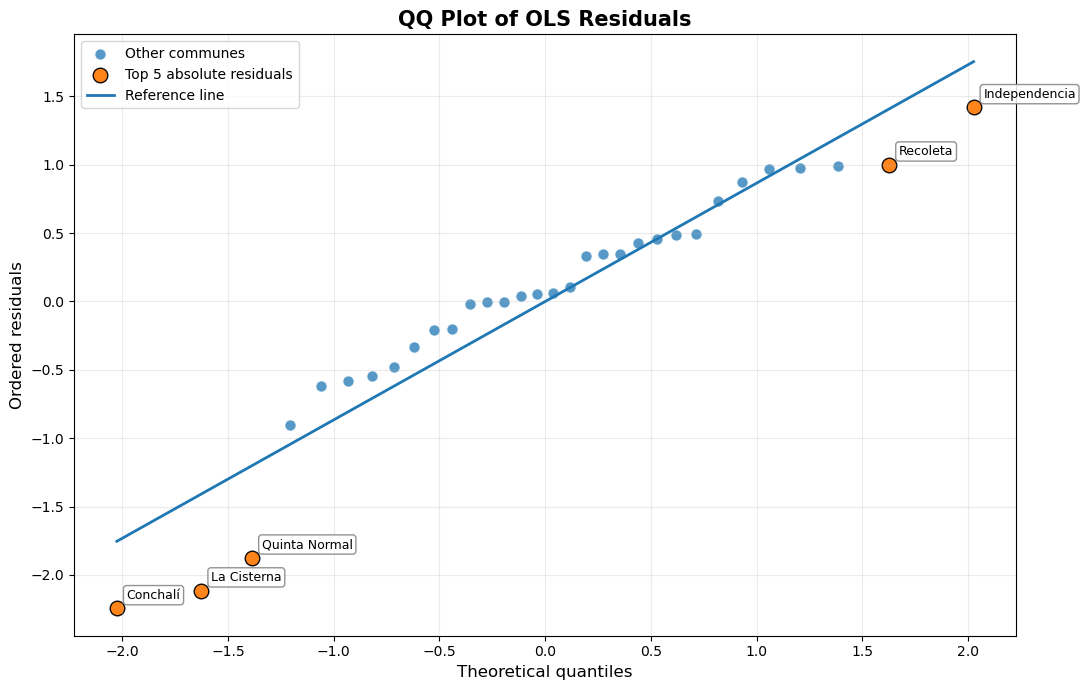

Top 5 communes with the largest absolute residuals


,codigo_comuna,nombre_comuna,grd_mortality_rate,fitted_values,residuals,abs_residual
0,13104,Conchalí,0.036834,2.282106,-2.245273,2.245273
1,13109,La Cisterna,0.037885,2.153120,-2.115235,2.115235
2,13126,Quinta Normal,0.033178,1.907830,-1.874652,1.874652
3,13108,Independencia,2.856332,1.436206,1.420126,1.420126
4,13127,Recoleta,2.977298,1.976648,1.000650,1.000650


Residual summary


,metric,value
0,count,3.200000e+01
1,mean,-5.551115e-17
2,std,8.752033e-01
3,min,-2.245273e+00
4,25%,-3.696649e-01
5,50%,5.775024e-02
6,75%,4.875339e-01
7,max,1.420126e+00


In [16]:
from scipy import stats

diagnostic_df = ols_mortality_data.copy()

# Verificar columnas necesarias
required_cols = [
    "codigo_comuna",
    "nombre_comuna",
    "grd_mortality_rate",
    "fitted_values",
    "residuals"
]

missing_cols = [col for col in required_cols if col not in diagnostic_df.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas para los diagnósticos: {missing_cols}")

# --------------------------------------------------
# Identificar comunas con residuos más extremos
# --------------------------------------------------

diagnostic_df["abs_residual"] = diagnostic_df["residuals"].abs()
top_extreme = diagnostic_df.sort_values("abs_residual", ascending=False).head(5).copy()

# Estandarizar residuos para referencia visual
resid_std = diagnostic_df["residuals"].std(ddof=1)
diagnostic_df["std_residual"] = diagnostic_df["residuals"] / resid_std

# --------------------------------------------------
# Plot 1 - Residuals vs Fitted
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

# Puntos base
ax.scatter(
    diagnostic_df["fitted_values"],
    diagnostic_df["residuals"],
    s=70,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.8,
    label="Other communes"
)

# Línea horizontal en 0
ax.axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)

# Bandas de referencia
ax.axhline(2 * resid_std, color="gray", linestyle=":", linewidth=1, alpha=0.7)
ax.axhline(-2 * resid_std, color="gray", linestyle=":", linewidth=1, alpha=0.7)

# Resaltar comunas extremas
ax.scatter(
    top_extreme["fitted_values"],
    top_extreme["residuals"],
    s=110,
    alpha=0.95,
    edgecolor="black",
    linewidth=1.0,
    label="Top 5 absolute residuals"
)

# Etiquetas
for _, row in top_extreme.iterrows():
    ax.annotate(
        row["nombre_comuna"],
        (row["fitted_values"], row["residuals"]),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.85)
    )

ax.set_title("Residuals vs Fitted Values", fontsize=15, fontweight="bold")
ax.set_xlabel("Fitted values", fontsize=12)
ax.set_ylabel("Residuals", fontsize=12)
ax.grid(True, alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 2 - QQ Plot mejorado
# --------------------------------------------------

# Obtener cuantiles teóricos y residuos ordenados
qq = stats.probplot(diagnostic_df["residuals"], dist="norm")
theoretical_q = qq[0][0]
ordered_resid = qq[0][1]
slope, intercept, r = qq[1]

# Crear tabla para poder etiquetar puntos
qq_df = diagnostic_df[["nombre_comuna", "residuals", "abs_residual"]].copy()
qq_df = qq_df.sort_values("residuals").reset_index(drop=True)
qq_df["theoretical_quantile"] = theoretical_q
qq_df["ordered_residual"] = ordered_resid

# Marcar los 5 residuos absolutos más extremos también en QQ plot
extreme_names = top_extreme["nombre_comuna"].tolist()
qq_df["is_extreme"] = qq_df["nombre_comuna"].isin(extreme_names)

fig, ax = plt.subplots(figsize=(11, 7))

# Puntos base
ax.scatter(
    qq_df.loc[~qq_df["is_extreme"], "theoretical_quantile"],
    qq_df.loc[~qq_df["is_extreme"], "ordered_residual"],
    s=65,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.8,
    label="Other communes"
)

# Puntos extremos
ax.scatter(
    qq_df.loc[qq_df["is_extreme"], "theoretical_quantile"],
    qq_df.loc[qq_df["is_extreme"], "ordered_residual"],
    s=110,
    alpha=0.95,
    edgecolor="black",
    linewidth=1.0,
    label="Top 5 absolute residuals"
)

# Línea teórica
x_line = np.linspace(qq_df["theoretical_quantile"].min(), qq_df["theoretical_quantile"].max(), 200)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, linewidth=2, label="Reference line")

# Etiquetas de comunas extremas
for _, row in qq_df[qq_df["is_extreme"]].iterrows():
    ax.annotate(
        row["nombre_comuna"],
        (row["theoretical_quantile"], row["ordered_residual"]),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.85)
    )

ax.set_title("QQ Plot of OLS Residuals", fontsize=15, fontweight="bold")
ax.set_xlabel("Theoretical quantiles", fontsize=12)
ax.set_ylabel("Ordered residuals", fontsize=12)
ax.grid(True, alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Tabla resumen de comunas más extremas
# --------------------------------------------------

print("Top 5 communes with the largest absolute residuals")
display(
    top_extreme[
        [
            "codigo_comuna",
            "nombre_comuna",
            "grd_mortality_rate",
            "fitted_values",
            "residuals",
            "abs_residual"
        ]
    ].reset_index(drop=True)
)

# --------------------------------------------------
# Residual summary
# --------------------------------------------------

residual_summary = pd.DataFrame({
    "metric": [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ],
    "value": [
        diagnostic_df["residuals"].count(),
        diagnostic_df["residuals"].mean(),
        diagnostic_df["residuals"].std(),
        diagnostic_df["residuals"].min(),
        diagnostic_df["residuals"].quantile(0.25),
        diagnostic_df["residuals"].median(),
        diagnostic_df["residuals"].quantile(0.75),
        diagnostic_df["residuals"].max()
    ]
})

print("Residual summary")
display(residual_summary)

- The graphs show that the OLS model does not exhibit significant bias overall, as the mean residual is close to zero. Similarly, the plot of residuals versus fitted values ​​reveals some clear outliers, particularly in Conchalí, La Cisterna, Quinta Normal, Independencia, and Recoleta.
- In the QQ plot, we can see that the residuals are visibly concentrated in the center, but the tails deviate from the reference line. This indicates that the assumptions of the OLS model are only partially met.

As a group, we propose considering a transformation of grd_mortality_rate, a robust regression, or a different continuous response variable.

## Part 4: Ecological Fallacy (1 pt)

All the results in this task are ecological because we worked with data at the comuna level, not with individual people. This means that each row in our database represents a place, not a specific person. For example, we observe the percentage of foreign-born residents in each comuna, the share of households without fixed internet access, and the number of ENO or GRD cases recorded. To make individual-level claims, we would need different data, such as whether a specific person was born abroad and whether that same person was notified with an ENO disease. What we have instead are patterns across comunas, and those patterns cannot be directly applied to the individuals who live there.

A concrete example is what happened with pct_foreign. In the Poisson model, it appeared significant and had a positive association with ENO cases. However, after correcting for overdispersion with the Negative Binomial model, that significance disappeared. Even if it had remained significant, it would still be wrong to say that immigrants are more likely to get sick. The correct interpretation is more limited: some comunas with a higher foreign-born population also had more ENO notifications, but the reasons behind this could be many, such as local working conditions, access to healthcare, reporting practices, or other comuna-level factors.

Even so, this type of ecological analysis is still useful for public health. pct_no_internet remained significant in the Negative Binomial model and also appeared consistently in the exploratory analysis. This does not mean that a person without internet is more likely to become sick. However, it does suggest that comunas with lower internet access may also be more isolated in general, with weaker access to information and public services. That is useful for deciding where prevention campaigns, health communication, or follow-up efforts may need more attention.

San Pedro and Melipilla also stood out as unusual cases in the ENO and GRD rates, respectively. There may be something specific about these comunas, such as rural conditions, their connection to nearby hospitals, or differences in how data are recorded. Still, we cannot make direct claims about the people who live there based only on these comuna-level results.

Finally, it is important to recognize that our models do not capture everything. Variables such as distance to hospitals, local healthcare capacity, or specific disease outbreaks were not included. We also did not account for the fact that neighboring comunas may be similar for reasons that go beyond the variables in our dataset. These limitations affect what we can conclude, and a natural next step would be to include more of these local and spatial factors in future analysis.

## Part 5: Spatial Visualization of Model Output (1 pt)

### 5.1 Predicted-rate map

Predicted ENO rates


,codigo_comuna,nombre_comuna,eno_total,eno_rate_per_10k,predicted_eno_count,predicted_eno_rate_per_10k
26,13505,San Pedro,731,609.166667,346.809897,312.216328
3,13108,Independencia,1642,156.380952,2173.923569,185.895998
14,13127,Recoleta,1978,104.105263,2130.907462,137.820228
23,13501,Melipilla,824,60.440000,1825.086507,133.877609
13,13126,Quinta Normal,1361,105.217586,1435.450292,110.973266
0,13104,Conchalí,1134,93.266550,1198.201786,98.546867
24,13502,Alhué,28,36.045314,75.503739,97.198428
22,13403,Calera de Tango,84,32.952807,217.604539,85.365242
16,13131,San Ramón,687,90.392358,621.505693,81.774913
4,13109,La Cisterna,714,69.214886,764.744435,74.134032



Columna de código comunal detectada en shapefile: cod_comuna
Coincidencias encontradas: 32


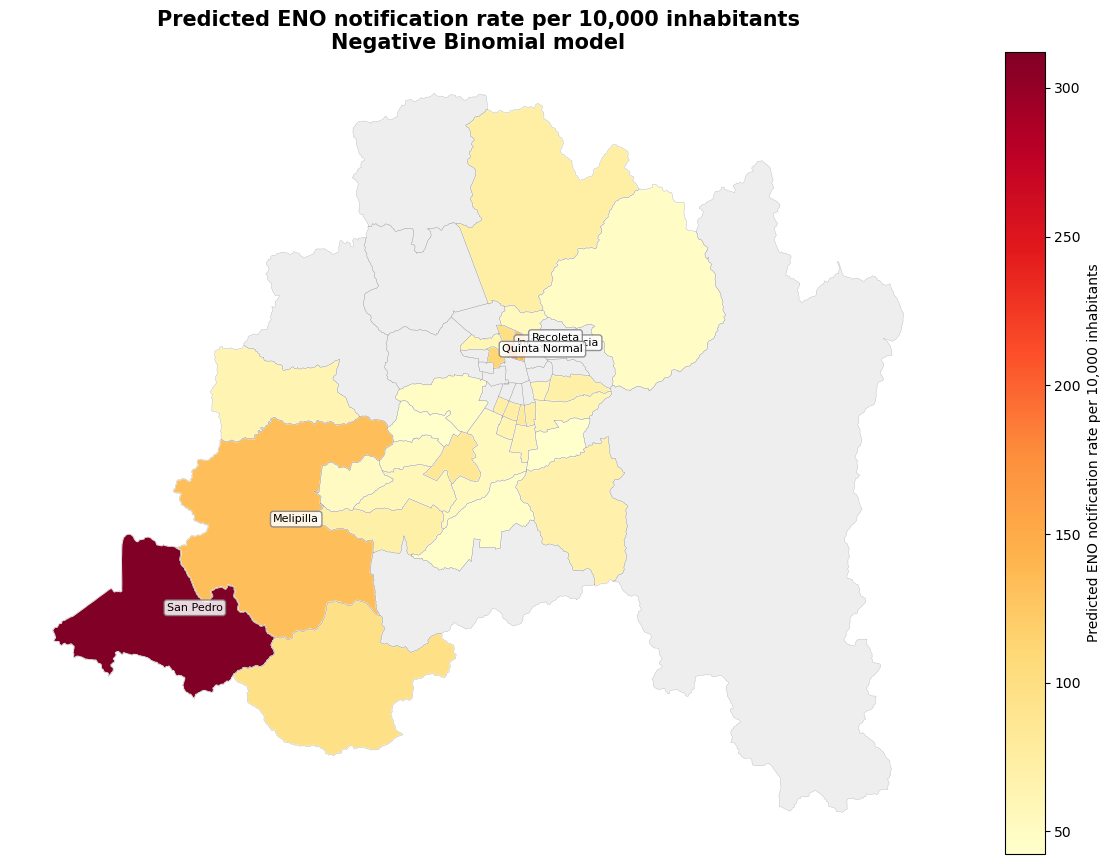


Summary of predicted ENO rates per 10,000


,value
count,32.000000
mean,81.734024
std,52.268843
min,42.415645
25%,54.801994
50%,66.390600
75%,82.672495
max,312.216328



All comunas by predicted ENO rate


,codigo_comuna,nombre_comuna,eno_rate_per_10k,predicted_eno_rate_per_10k
0,13505,San Pedro,609.166667,312.216328
1,13108,Independencia,156.380952,185.895998
2,13127,Recoleta,104.105263,137.820228
3,13501,Melipilla,60.440000,133.877609
4,13126,Quinta Normal,105.217586,110.973266
5,13104,Conchalí,93.266550,98.546867
6,13502,Alhué,36.045314,97.198428
7,13403,Calera de Tango,32.952807,85.365242
8,13131,San Ramón,90.392358,81.774913
9,13109,La Cisterna,69.214886,74.134032


In [18]:
import geopandas as gpd

map_data = analytical_table.copy()

# Mismas covariables usadas en el modelo Negative Binomial de ENO
covariates = [
    "pct_foreign",
    "schooling_gap",
    "employment_gap",
    "pct_no_internet"
]

required_cols = [
    "codigo_comuna",
    "nombre_comuna",
    "pop_total"
] + covariates

missing_cols = [col for col in required_cols if col not in map_data.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas para calcular predicciones: {missing_cols}")

# Verificar que el modelo NB de ENO exista
if "nb_eno_model" not in globals():
    raise ValueError("No se encontró nb_eno_model. Corre primero la sección 2.3.")

# Asegurar formato numérico
for col in ["pop_total"] + covariates:
    map_data[col] = pd.to_numeric(map_data[col], errors="coerce")

map_data = map_data.dropna(subset=["pop_total"] + covariates).copy()

if (map_data["pop_total"] <= 0).any():
    raise ValueError("Hay comunas con pop_total <= 0. No se puede calcular el offset.")

# --------------------------------------------------
# 2. Calcular predicciones del modelo Negative Binomial
# --------------------------------------------------

X_pred = sm.add_constant(map_data[covariates], has_constant="add")
offset_pred = np.log(map_data["pop_total"])

# Usamos los coeficientes del modelo NB, excluyendo alpha
beta = nb_eno_model.params.drop("alpha", errors="ignore")

# Alinear columnas del X con los coeficientes del modelo
X_pred = X_pred[beta.index]

linear_prediction = X_pred @ beta + offset_pred

map_data["predicted_eno_count"] = np.exp(linear_prediction)
map_data["predicted_eno_rate_per_10k"] = (
    map_data["predicted_eno_count"] / map_data["pop_total"] * 10000
)

print("Predicted ENO rates")
display(
    map_data[
        [
            "codigo_comuna",
            "nombre_comuna",
            "eno_total",
            "eno_rate_per_10k",
            "predicted_eno_count",
            "predicted_eno_rate_per_10k"
        ]
    ]
    .sort_values("predicted_eno_rate_per_10k", ascending=False)
    .head(10)
)

# --------------------------------------------------
# 3. Leer shapefile de comunas
# --------------------------------------------------

shp_path = Path("../Datos/comunas.shp")

if not shp_path.exists():
    raise FileNotFoundError(f"No se encontró el shapefile en: {shp_path}")

comunas_gdf = gpd.read_file(shp_path)

# --------------------------------------------------
# 4. Detectar columna de código comunal en el shapefile
# --------------------------------------------------

target_codes = set(map_data["codigo_comuna"].dropna().astype(int))

best_code_col = None
best_matches = -1

for col in comunas_gdf.columns:
    if col == "geometry":
        continue
    
    temp_codes = pd.to_numeric(comunas_gdf[col], errors="coerce")
    matches = temp_codes.dropna().astype(int).isin(target_codes).sum()
    
    if matches > best_matches:
        best_matches = matches
        best_code_col = col

if best_code_col is None or best_matches == 0:
    raise ValueError(
        "No se pudo identificar una columna de código comunal en el shapefile. "
        "Revisa las columnas de comunas_gdf."
    )

print("\nColumna de código comunal detectada en shapefile:", best_code_col)
print("Coincidencias encontradas:", best_matches)

comunas_gdf["codigo_comuna"] = pd.to_numeric(
    comunas_gdf[best_code_col],
    errors="coerce"
).astype("Int64")

# Filtrar Región Metropolitana si corresponde
# Los códigos comunales RM comienzan con 13
comunas_rm = comunas_gdf[
    comunas_gdf["codigo_comuna"].astype(str).str.startswith("13")
].copy()

# Si el filtro RM queda vacío, usamos todo el shapefile
if comunas_rm.empty:
    comunas_rm = comunas_gdf.copy()

# Evitar duplicados geométricos
comunas_rm = comunas_rm.drop_duplicates(subset=["codigo_comuna"]).copy()

# --------------------------------------------------
# 5. Unir predicciones con geometría
# --------------------------------------------------

map_plot = comunas_rm.merge(
    map_data[
        [
            "codigo_comuna",
            "nombre_comuna",
            "predicted_eno_rate_per_10k"
        ]
    ],
    on="codigo_comuna",
    how="left"
)

# --------------------------------------------------
# 6. Mapa coroplético
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 11))

# Comunas sin datos en gris claro
map_plot.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="white",
    linewidth=0.6
)

# Comunas con predicción
map_plot.dropna(subset=["predicted_eno_rate_per_10k"]).plot(
    column="predicted_eno_rate_per_10k",
    ax=ax,
    cmap="YlOrRd",
    edgecolor="white",
    linewidth=0.8,
    legend=True,
    legend_kwds={
        "label": "Predicted ENO notification rate per 10,000 inhabitants",
        "shrink": 0.75
    }
)

# Contorno general
map_plot.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=0.3,
    alpha=0.6
)

# Etiquetar las 5 comunas con mayor tasa predicha
top_predicted = (
    map_plot
    .dropna(subset=["predicted_eno_rate_per_10k"])
    .sort_values("predicted_eno_rate_per_10k", ascending=False)
    .head(5)
    .copy()
)

for _, row in top_predicted.iterrows():
    point = row.geometry.representative_point()
    ax.annotate(
        row["nombre_comuna"],
        xy=(point.x, point.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="gray",
            alpha=0.85
        )
    )

ax.set_title(
    "Predicted ENO notification rate per 10,000 inhabitants\nNegative Binomial model",
    fontsize=15,
    fontweight="bold"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. Resumen de tasas predichas
# --------------------------------------------------

print("\nSummary of predicted ENO rates per 10,000")
display(
    map_data["predicted_eno_rate_per_10k"]
    .describe()
    .to_frame(name="value")
)

print("\nAll comunas by predicted ENO rate")
display(
    map_data[
        [
            "codigo_comuna",
            "nombre_comuna",
            "eno_rate_per_10k",
            "predicted_eno_rate_per_10k"
        ]
    ]
    .sort_values("predicted_eno_rate_per_10k", ascending=False)
    .reset_index(drop=True)
)

This part was developed from Part 2, using the Negative Binomial model. The predicted counts were converted into rates per 10,000 inhabitants using the population of each municipality.
The map shows that San Pedro has the highest predicted ENO notification rate, clearly standing out from the other municipalities. Other municipalities with relatively high predicted rates include Independencia, Recoleta, Melipilla, and Quinta Normal. Overall, the map helps identify where the model predicts higher ENO notification rates, while also showing that the pattern is spatially concentrated rather than evenly distributed across the region.

### 5.2 Residual map

Residual summary


,value
count,32.000000
mean,-0.004017
std,0.977355
min,-1.626094
25%,-0.592890
50%,-0.091920
75%,0.489941
max,2.742378



Largest positive residuals


,codigo_comuna,nombre_comuna,eno_total,predicted_eno_count,pearson_residual
26,13505,San Pedro,731,346.809897,2.742378
17,13201,Puente Alto,4334,2446.549840,1.924476
2,13107,Huechuraba,832,559.088627,1.212482
7,13112,La Pintana,1507,1067.332001,1.025897
11,13119,maipu,3316,2491.506201,0.825518



Largest negative residuals


,codigo_comuna,nombre_comuna,eno_total,predicted_eno_count,pearson_residual
25,13504,María Pinto,32,97.427693,-1.626094
22,13403,Calera de Tango,84,217.604539,-1.512026
24,13502,Alhué,28,75.503739,-1.510303
29,13603,Isla de Maipo,115,276.063276,-1.441051
23,13501,Melipilla,824,1825.086507,-1.367701



Columna de código comunal detectada en shapefile: cod_comuna
Coincidencias encontradas: 32


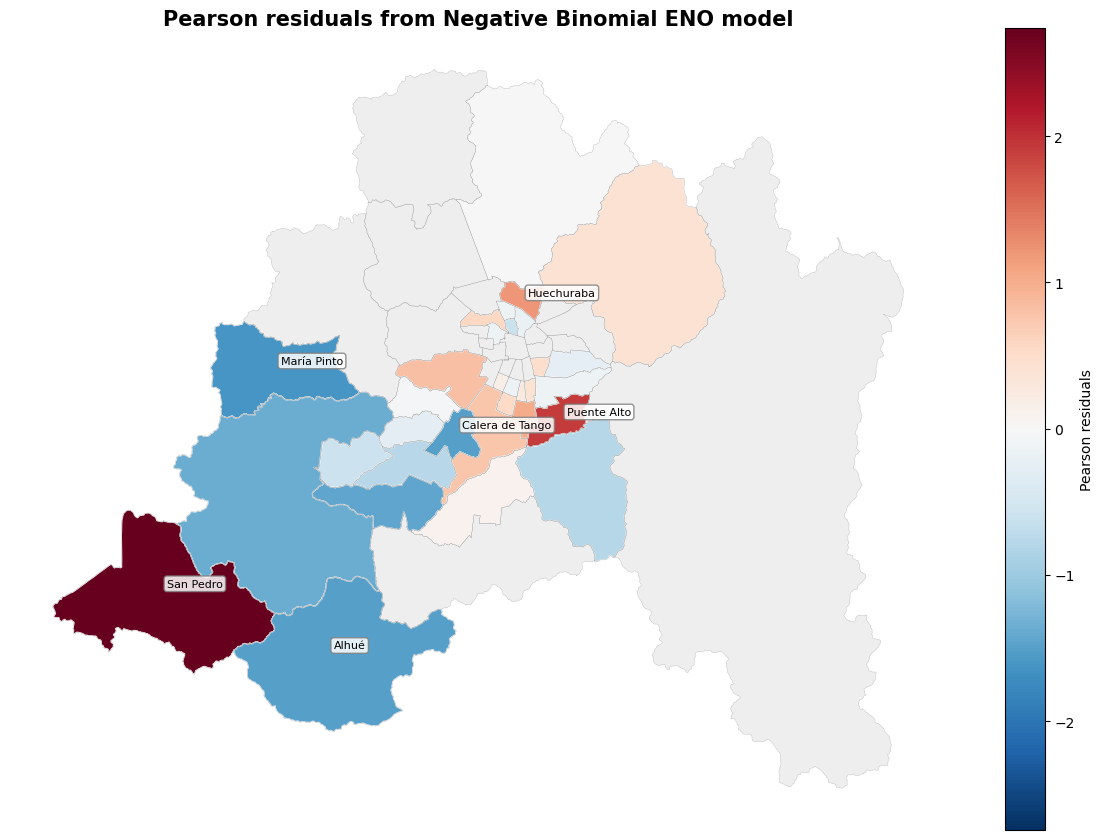


All comunas by Pearson residual


,codigo_comuna,nombre_comuna,eno_total,predicted_eno_count,pearson_residual
0,13505,San Pedro,731,346.809897,2.742378
1,13201,Puente Alto,4334,2446.549840,1.924476
2,13107,Huechuraba,832,559.088627,1.212482
3,13112,La Pintana,1507,1067.332001,1.025897
4,13119,maipu,3316,2491.506201,0.825518
5,13401,San Bernardo,2172,1668.497430,0.752332
6,13128,Renca,1064,866.915579,0.565799
7,13105,El Bosque,1212,995.536758,0.541395
8,13118,Macul,890,747.851228,0.472790
9,13115,Lo Barnechea,630,540.323660,0.412169


In [19]:
from matplotlib.colors import TwoSlopeNorm

resid_data = analytical_table.copy()

covariates = [
    "pct_foreign",
    "schooling_gap",
    "employment_gap",
    "pct_no_internet"
]

required_cols = [
    "codigo_comuna",
    "nombre_comuna",
    "pop_total",
    "eno_total"
] + covariates

missing_cols = [col for col in required_cols if col not in resid_data.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas para calcular residuos: {missing_cols}")

if "nb_eno_model" not in globals():
    raise ValueError("No se encontró nb_eno_model. Corre primero la sección 2.3.")

for col in ["pop_total", "eno_total"] + covariates:
    resid_data[col] = pd.to_numeric(resid_data[col], errors="coerce")

resid_data = resid_data.dropna(subset=["pop_total", "eno_total"] + covariates).copy()

if (resid_data["pop_total"] <= 0).any():
    raise ValueError("Hay comunas con pop_total <= 0.")

# --------------------------------------------------
# 2. Predicciones y residuos Pearson
# --------------------------------------------------

X_resid = sm.add_constant(resid_data[covariates], has_constant="add")
offset_resid = np.log(resid_data["pop_total"])

# Coeficientes del modelo NB, excluyendo alpha
beta = nb_eno_model.params.drop("alpha", errors="ignore")
X_resid = X_resid[beta.index]

# Media predicha
linear_pred = X_resid @ beta + offset_resid
resid_data["predicted_eno_count"] = np.exp(linear_pred)

# Alpha del modelo NB
alpha = nb_eno_model.params.get("alpha", 0)

# Varianza del modelo Negative Binomial
# Var(Y) = mu + alpha * mu^2
resid_data["nb_variance"] = (
    resid_data["predicted_eno_count"] +
    alpha * resid_data["predicted_eno_count"] ** 2
)

# Pearson residual
resid_data["pearson_residual"] = (
    (resid_data["eno_total"] - resid_data["predicted_eno_count"]) /
    np.sqrt(resid_data["nb_variance"])
)

print("Residual summary")
display(
    resid_data["pearson_residual"]
    .describe()
    .to_frame(name="value")
)

print("\nLargest positive residuals")
display(
    resid_data[
        [
            "codigo_comuna",
            "nombre_comuna",
            "eno_total",
            "predicted_eno_count",
            "pearson_residual"
        ]
    ]
    .sort_values("pearson_residual", ascending=False)
    .head(5)
)

print("\nLargest negative residuals")
display(
    resid_data[
        [
            "codigo_comuna",
            "nombre_comuna",
            "eno_total",
            "predicted_eno_count",
            "pearson_residual"
        ]
    ]
    .sort_values("pearson_residual", ascending=True)
    .head(5)
)

# --------------------------------------------------
# 3. Leer shapefile
# --------------------------------------------------

shp_path = Path("../Datos/comunas.shp")

if not shp_path.exists():
    raise FileNotFoundError(f"No se encontró el shapefile en: {shp_path}")

comunas_gdf = gpd.read_file(shp_path)

# Detectar columna de código comunal
target_codes = set(resid_data["codigo_comuna"].dropna().astype(int))

best_code_col = None
best_matches = -1

for col in comunas_gdf.columns:
    if col == "geometry":
        continue

    temp_codes = pd.to_numeric(comunas_gdf[col], errors="coerce")
    matches = temp_codes.dropna().astype(int).isin(target_codes).sum()

    if matches > best_matches:
        best_matches = matches
        best_code_col = col

if best_code_col is None or best_matches == 0:
    raise ValueError("No se pudo identificar una columna de código comunal en el shapefile.")

print("\nColumna de código comunal detectada en shapefile:", best_code_col)
print("Coincidencias encontradas:", best_matches)

comunas_gdf["codigo_comuna"] = pd.to_numeric(
    comunas_gdf[best_code_col],
    errors="coerce"
).astype("Int64")

# Filtrar Región Metropolitana
comunas_rm = comunas_gdf[
    comunas_gdf["codigo_comuna"].astype(str).str.startswith("13")
].copy()

if comunas_rm.empty:
    comunas_rm = comunas_gdf.copy()

comunas_rm = comunas_rm.drop_duplicates(subset=["codigo_comuna"]).copy()

# --------------------------------------------------
# 4. Unir residuos con geometría
# --------------------------------------------------

resid_map = comunas_rm.merge(
    resid_data[
        [
            "codigo_comuna",
            "nombre_comuna",
            "eno_total",
            "predicted_eno_count",
            "pearson_residual"
        ]
    ],
    on="codigo_comuna",
    how="left"
)

# --------------------------------------------------
# 5. Residual map
# --------------------------------------------------

max_abs_resid = resid_map["pearson_residual"].abs().max()

norm = TwoSlopeNorm(
    vmin=-max_abs_resid,
    vcenter=0,
    vmax=max_abs_resid
)

fig, ax = plt.subplots(figsize=(12, 11))

# Comunas sin datos
resid_map.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="white",
    linewidth=0.6
)

# Comunas con residuos
resid_map.dropna(subset=["pearson_residual"]).plot(
    column="pearson_residual",
    ax=ax,
    cmap="RdBu_r",
    norm=norm,
    edgecolor="white",
    linewidth=0.8,
    legend=True,
    legend_kwds={
        "label": "Pearson residuals",
        "shrink": 0.75
    }
)

# Contorno
resid_map.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=0.3,
    alpha=0.6
)

# Etiquetar comunas con residuos más extremos
top_positive = (
    resid_map
    .dropna(subset=["pearson_residual"])
    .sort_values("pearson_residual", ascending=False)
    .head(3)
)

top_negative = (
    resid_map
    .dropna(subset=["pearson_residual"])
    .sort_values("pearson_residual", ascending=True)
    .head(3)
)

top_labels = pd.concat([top_positive, top_negative]).drop_duplicates("codigo_comuna")

for _, row in top_labels.iterrows():
    point = row.geometry.representative_point()
    ax.annotate(
        row["nombre_comuna"],
        xy=(point.x, point.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="gray",
            alpha=0.85
        )
    )

ax.set_title(
    "Pearson residuals from Negative Binomial ENO model",
    fontsize=15,
    fontweight="bold"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. Tabla completa de residuos
# --------------------------------------------------

print("\nAll comunas by Pearson residual")
display(
    resid_data[
        [
            "codigo_comuna",
            "nombre_comuna",
            "eno_total",
            "predicted_eno_count",
            "pearson_residual"
        ]
    ]
    .sort_values("pearson_residual", ascending=False)
    .reset_index(drop=True)
)

As we can see, the residual map shows where the Negative Binomial model fits best and worst. Positive residuals indicate that the number of observed ENO cases was higher than predicted by the model, and these are visually represented by the red areas. Negative residuals indicate that the model predicted more cases than were actually observed, and these are visually represented by the blue areas.
The strongest positive residual is in San Pedro, with a Pearson residual of about 2.74, meaning that this comuna had more ENO reports than expected, even after considering the selected covariates. Other positive residuals appear in Puente Alto, Huechuraba, and La Pintana, but they are less pronounced. On the other hand, María Pinto, Calera de Tango, Alhué, Isla de Maipo, and Melipilla had fewer ENO cases than predicted. As can be seen from the graph, the residuals are fairly centered around zero, so the model seems to fit most comunas reasonably well, although some areas still show differences.

### 5.3 Coefficient plot

IRR table used for coefficient plot


,variable,coef,IRR,IRR_lower,IRR_upper,p_value
employment_gap,employment_gap,-0.095014,0.909360,0.821221,1.006958,0.067752
pct_no_internet,pct_no_internet,0.020941,1.021161,1.007641,1.034864,0.002076
pct_foreign,pct_foreign,0.021707,1.021944,0.999370,1.045029,0.056828
schooling_gap,schooling_gap,0.105751,1.111545,0.788022,1.567890,0.546802


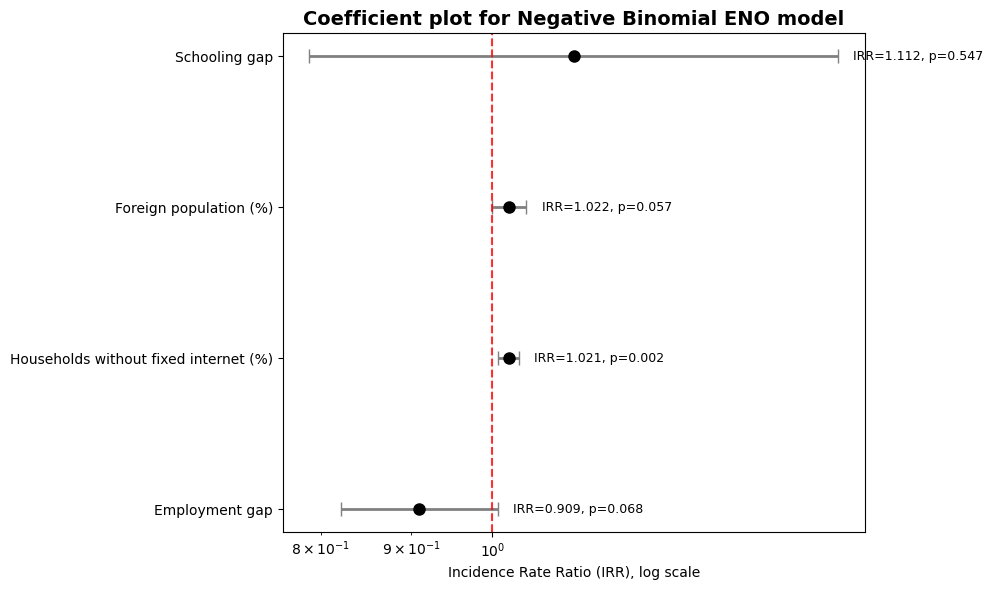

In [20]:
if "nb_eno_model" not in globals():
    raise ValueError("No se encontró nb_eno_model. Corre primero la sección 2.3.")

# Covariables del modelo principal
coef_vars = [
    "pct_foreign",
    "schooling_gap",
    "employment_gap",
    "pct_no_internet"
]

# Extraer coeficientes e intervalos
params = nb_eno_model.params
conf_int = nb_eno_model.conf_int()
conf_int.columns = ["coef_lower", "coef_upper"]

# Crear tabla solo con covariables
coef_plot_table = pd.DataFrame({
    "variable": coef_vars,
    "coef": params[coef_vars],
    "coef_lower": conf_int.loc[coef_vars, "coef_lower"],
    "coef_upper": conf_int.loc[coef_vars, "coef_upper"],
    "p_value": nb_eno_model.pvalues[coef_vars]
})

# Convertir a IRR
coef_plot_table["IRR"] = np.exp(coef_plot_table["coef"])
coef_plot_table["IRR_lower"] = np.exp(coef_plot_table["coef_lower"])
coef_plot_table["IRR_upper"] = np.exp(coef_plot_table["coef_upper"])

# Nombres más legibles para el gráfico
label_map = {
    "pct_foreign": "Foreign population (%)",
    "schooling_gap": "Schooling gap",
    "employment_gap": "Employment gap",
    "pct_no_internet": "Households without fixed internet (%)"
}

coef_plot_table["label"] = coef_plot_table["variable"].map(label_map)

# Ordenar para que se vea más limpio
coef_plot_table = coef_plot_table.sort_values("IRR")

print("IRR table used for coefficient plot")
display(
    coef_plot_table[
        ["variable", "coef", "IRR", "IRR_lower", "IRR_upper", "p_value"]
    ]
)

# --------------------------------------------------
# Coefficient plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(coef_plot_table))

# Error bars asimétricos
xerr_lower = coef_plot_table["IRR"] - coef_plot_table["IRR_lower"]
xerr_upper = coef_plot_table["IRR_upper"] - coef_plot_table["IRR"]

ax.errorbar(
    coef_plot_table["IRR"],
    y_pos,
    xerr=[xerr_lower, xerr_upper],
    fmt="o",
    markersize=8,
    capsize=5,
    linewidth=2,
    color="black",
    ecolor="gray"
)

# Línea nula IRR = 1
ax.axvline(
    1,
    linestyle="--",
    linewidth=1.5,
    color="red",
    alpha=0.8
)

# Etiquetas con IRR y p-value
for i, row in coef_plot_table.iterrows():
    ax.text(
        row["IRR_upper"] * 1.02,
        y_pos[list(coef_plot_table.index).index(i)],
        f"IRR={row['IRR']:.3f}, p={row['p_value']:.3f}",
        va="center",
        fontsize=9
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(coef_plot_table["label"])

ax.set_xscale("log")
ax.set_xlabel("Incidence Rate Ratio (IRR), log scale")
ax.set_title(
    "Coefficient plot for Negative Binomial ENO model",
    fontsize=14,
    fontweight="bold"
)

ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

The coefficient graph shows the IRR estimates for the negative binomial ENO model. The red vertical line indicates IRR = 1, meaning there is no clear change in the expected ENO notification rate.
Among the covariates, pct_no_internet shows the clearest result, with an IRR greater than 1 and a p-value less than 0.05. This tells us that municipalities with a higher percentage of households without fixed internet tend to have higher expected ENO notification rates. The other variables show wider ranges or p-values ​​greater than 0.05, so their effects should be interpreted with caution.

## Part 6: Integrated Synthesis (1.5 pts)

Across the three parts of the analysis, the clearest finding is that the comunas of the Región Metropolitana are not homogeneous, neither in their demographic composition nor in their health outcomes. At the beginning, the pooled files covered 52 different comunas, but the final analysis used 32 of them because some files had data quality problems or inconsistencies. From the start, it was clear that there were very different types of comunas, especially between more urban and central areas and more peripheral or rural ones.

Two variables showed this difference especially well. The first one is pct_foreign, which had an average close to 9.9%, but reached up to 44.4% in some comunas. This shows that migration is not evenly distributed across the territory. The second one is pct_no_internet, with an average of 31.3%, but with some comunas where almost 80% of households did not have fixed internet access. This gap in connectivity says more than just internet access, since it can also reflect differences in access to information, services, and resources in general.

It is important to note that ENO and GRD do not cover the same time window. ENO summarizes notifications from 2007 to 2024, while GRD covers 2022 to 2024. Because of this, raw counts from both sources should not be compared directly. For that reason, the analysis focuses on rates, model-based comparisons, and separate interpretations for each outcome.

In terms of health, the clearest and most consistent relationship was between pct_no_internet and the ENO rate. In the exploratory analysis, the correlation was 0.68, and this relationship also remained important in the Negative Binomial model, which was the more appropriate model after checking the data. In contrast, the relationship between pct_foreign and ENO was much less stable. It appeared in the Poisson model, but disappeared after correcting for overdispersion.

San Pedro was the most noticeable case for ENO. It had the highest observed rate and also the highest predicted rate in the model, around 312 cases per 10,000 inhabitants. Even so, the model still underestimated San Pedro, which suggests that there is something about this comuna that our variables do not fully explain. On the other side, comunas such as María Pinto, Calera de Tango, and Melipilla had fewer cases than the model expected.

For GRD, the story was different. Melipilla stood out in the hospital discharge rate, possibly because it works as a health care center for nearby comunas. Still, this has to be interpreted carefully because the data are still at the comuna level. The most relevant result from the GRD analysis was that none of the variables remained significant in the Negative Binomial model. This suggests that hospital discharges may depend on factors that are not included in our database, such as bed availability, patient flows between comunas, or the complexity of cases.

What the models added beyond the exploratory analysis was precisely that. They showed that some relationships that looked strong in simple correlations became weaker or disappeared once other variables were included and the model problems were corrected. So, it is not enough to look only at a correlation and make a conclusion from it.

Overall, the strongest finding is not that one single variable explains everything, but that health differences between comunas seem to be connected with broader social conditions and access to services. The most stable signal was pct_no_internet in relation to ENO. Even so, all these results describe patterns between comunas, not between individual people. The models are useful for identifying places that may need more attention, but they cannot prove that a specific individual characteristic directly causes higher health risk.